# LSTM Tuning 1

Trial 200 Complete [00h 00m 20s]
val_loss: 0.004331789250361319

Best val_loss So Far: 0.0037565944643652687
Total elapsed time: 01h 22m 49s

  HYPERPARAMETER TERBAIK:
    window_size               = 5
    num_lstm_layers           = 1
    learning_rate             = 0.001
    batch_size                = 2
    lstm_units_0              = 64
    dropout_lstm_0            = 0.2
    lstm_units_1              = 32
    dropout_lstm_1            = 0.4
    lstm_units_2              = 64
    dropout_lstm_2            = 0.2

Sequence shapes (window=5, batch=2, lstm_layers=1):
  Train : (717, 5, 2)
  Val   : (38, 5, 2)
  Test  : (81, 5, 2)



Model: "sequential_203"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm_1 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model final dengan HP terbaik …
Epoch 1/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0869 - mae: 0.2433 - val_loss: 0.3823 - val_mae: 0.6134 - learning_rate: 0.0010
Epoch 2/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0396 - mae: 0.1591 - val_loss: 0.2218 - val_mae: 0.4667 - learning_rate: 0.0010
Epoch 3/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0297 - mae: 0.1342 - val_loss: 0.1261 - val_mae: 0.3510 - learning_rate: 0.0010
Epoch 4/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0202 - mae: 0.1054 - val_loss: 0.0975 - val_mae: 0.3082 - learning_rate: 0.0010
Epoch 5/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0129 - mae: 0.0771 - val_loss: 0.0634 - val_mae: 0.2474 - learning_rate: 0.0010
Epoch 6/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0102 - mae: 0.0696 - val_loss: 0.0512 - val_mae: 0.2220 - learning_rate: 0.0010
Epoch 7/300
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0078 - mae: 0.0601 - val_loss: 0.0253 

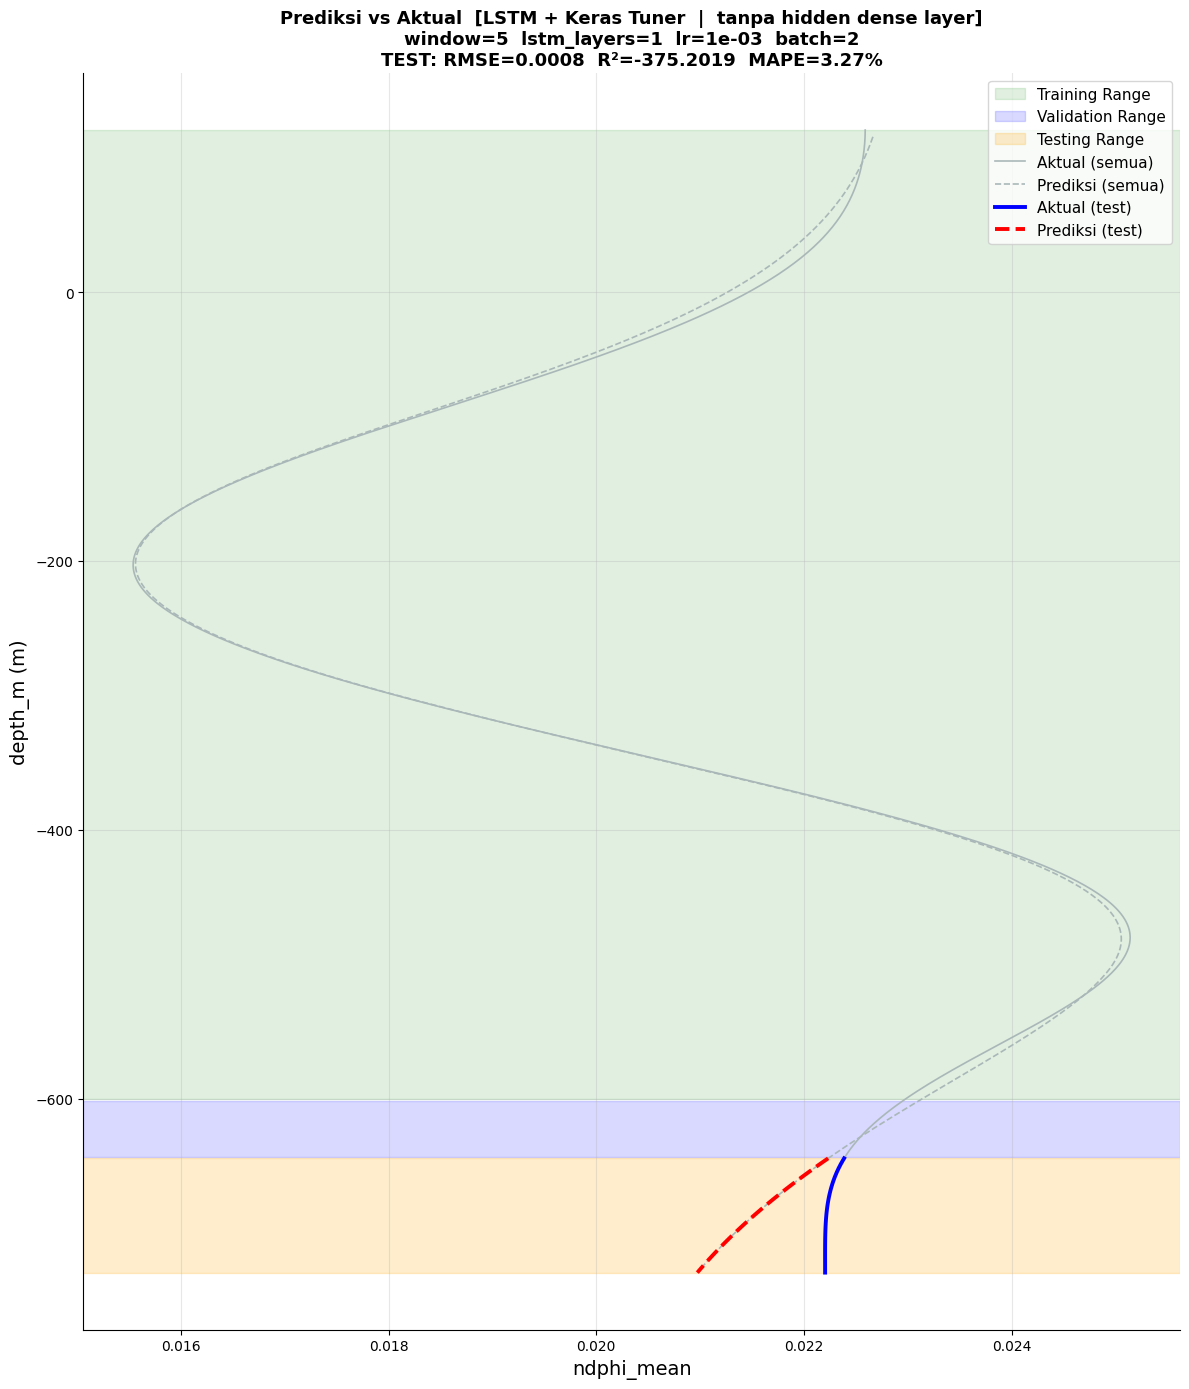

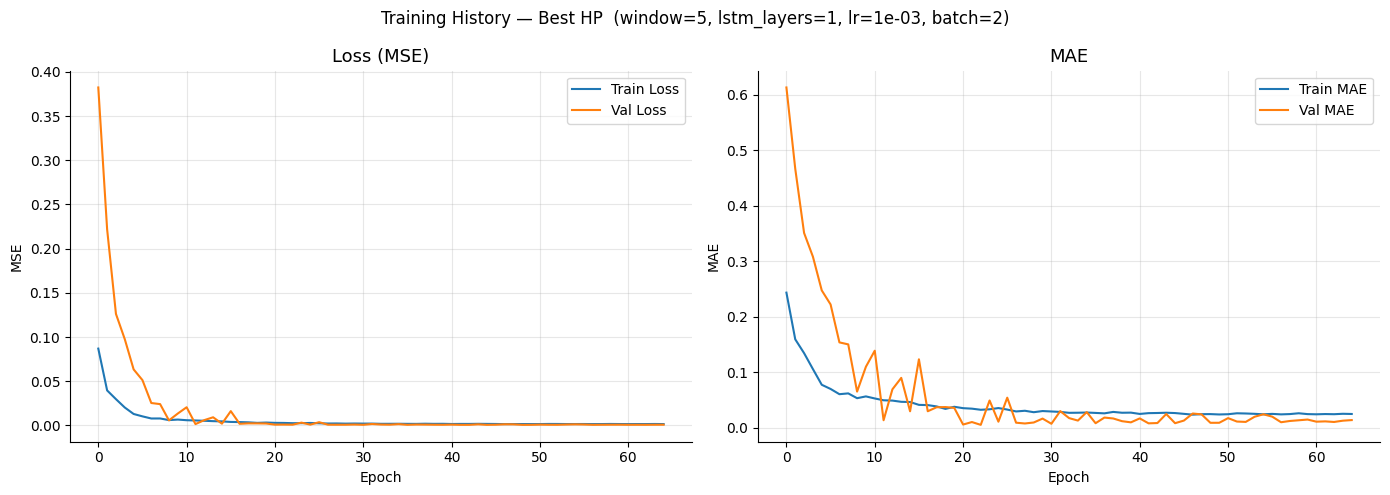

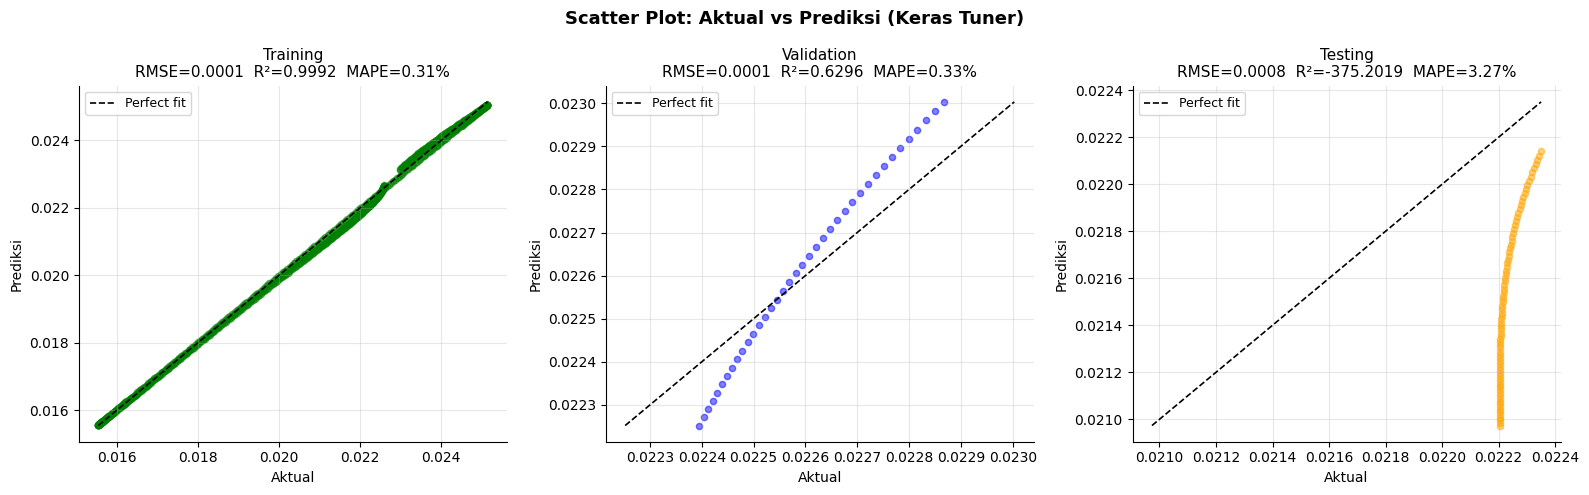


  TOP 5 TRIALS (Keras Tuner):
  #1  val_loss=0.003757
       window=5  lstm_layers=1  lr=1e-03  batch=2
       {'window_size': 5, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 2, 'lstm_units_0': 64, 'dropout_lstm_0': 0.2, 'lstm_units_1': 32, 'dropout_lstm_1': 0.4, 'lstm_units_2': 64, 'dropout_lstm_2': 0.2}
  #2  val_loss=0.003783
       window=5  lstm_layers=1  lr=1e-03  batch=2
       {'window_size': 5, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 2, 'lstm_units_0': 64, 'dropout_lstm_0': 0.1, 'lstm_units_1': 64, 'dropout_lstm_1': 0.30000000000000004, 'lstm_units_2': 64, 'dropout_lstm_2': 0.2}
  #3  val_loss=0.003863
       window=5  lstm_layers=1  lr=1e-03  batch=2
       {'window_size': 5, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 2, 'lstm_units_0': 64, 'dropout_lstm_0': 0.1, 'lstm_units_1': 64, 'dropout_lstm_1': 0.4, 'lstm_units_2': 32, 'dropout_lstm_2': 0.2}
  #4  val_loss=0.003953
       window=5  lstm_layers=1  lr=1e-03  batch=2
   

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import keras_tuner as kt
import math, os, random, joblib

# =============================================================================
# CONSTANTS
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# REPRODUCIBILITY
# =============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    print("Warning: deterministic ops not available on this device.")

# =============================================================================
# KERAS TUNER CONFIG
# =============================================================================
TUNER_DIR      = 'keras_tuner_results'
TUNER_PROJECT  = 'lstm_porosity'
MAX_TRIALS     = 200
TUNER_EPOCHS   = 50
TUNER_PATIENCE = 15
FINAL_EPOCHS   = 300
FINAL_PATIENCE = 20

# =============================================================================
# FILE PATHS
# =============================================================================
model_filename = 'model_A_lstm_tuned.keras'
scaler_X_path  = 'scaler_X_A_lstm_tuned.pkl'
scaler_y_path  = 'scaler_Y_A_lstm_tuned.pkl'
best_hp_path   = 'best_hp_lstm.pkl'
force_retrain  = True

# =============================================================================
# 1) LOAD & SORT DATA
# =============================================================================
try:
    data = pd.read_csv("resampled_1m_78B_AT90(ohm.m)_78.csv", sep=';')
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan!")
    exit()

print(f"Data berhasil dimuat: {len(data)} baris")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)
min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

train_percentage      = 0.85
validation_percentage = 0.05
test_percentage       = 0.10

test_limit     = min_z + z_range * test_percentage
test_mask      = data_sorted[DEPTH] <= test_limit
train_val_mask = ~test_mask

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[train_val_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit     = train_val_data[DEPTH].max() - train_val_range * (
    train_percentage / (1 - test_percentage))

train_data      = train_val_data[train_val_data[DEPTH] > train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"Range keseluruhan : {max_z:.2f}m – {min_z:.2f}m")
print(f"Training range    : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts)")
print(f"Validation range  : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts)")
print(f"Testing range     : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts)")

# =============================================================================
# 2) RAW FEATURE ARRAYS
# =============================================================================
X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

N_FEATURES = X_train_raw.shape[1]  # = 2

# =============================================================================
# 3) SCALERS  (fit on train only)
# =============================================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)
X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)
X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

# =============================================================================
# 4) SEQUENCE HELPER
# =============================================================================
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# =============================================================================
# 5) MODEL BUILDER — tuning jumlah LSTM layer {1, 2, 3}, tanpa hidden dense
# =============================================================================
def build_model(hp):
    window_size     = hp.Choice('window_size',     values=[3, 5, 10, 20, 30])
    num_lstm_layers = hp.Int   ('num_lstm_layers', min_value=1, max_value=3, step=1)
    lr              = hp.Choice('learning_rate',   values=[1e-3, 5e-4, 1e-4, 5e-5])
    hp.Choice('batch_size', values=[2, 4, 16, 32, 64])

    model = Sequential()

    # ── LSTM LAYERS ──────────────────────────────────────────────
    for i in range(num_lstm_layers):
        units        = hp.Choice(f'lstm_units_{i}',  values=[16, 32, 64])
        dropout_rate = hp.Float (f'dropout_lstm_{i}',
                                  min_value=0.1, max_value=0.4, step=0.1)
        is_last_lstm = (i == num_lstm_layers - 1)

        if i == 0:
            model.add(LSTM(
                units,
                input_shape=(window_size, N_FEATURES),
                return_sequences=not is_last_lstm,
                kernel_regularizer=l2(1e-3),
                kernel_initializer=GlorotUniform(seed=SEED),
                recurrent_initializer='orthogonal',
                name=f'lstm_{i+1}'
            ))
        else:
            model.add(LSTM(
                units,
                return_sequences=not is_last_lstm,
                kernel_regularizer=l2(1e-3),
                kernel_initializer=GlorotUniform(seed=SEED),
                recurrent_initializer='orthogonal',
                name=f'lstm_{i+1}'
            ))

        model.add(Dropout(dropout_rate, seed=SEED, name=f'drop_lstm_{i+1}'))

    # ── OUTPUT LAYER (langsung dari LSTM, tanpa hidden dense) ────
    model.add(Dense(
        1,
        activation='linear',
        kernel_initializer=GlorotUniform(seed=SEED),
        name='output'
    ))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=MeanSquaredError(),
        metrics=['mae'],
    )
    return model

# =============================================================================
# 6) CUSTOM TUNER
# =============================================================================
class WindowedLSTMTuner(kt.BayesianOptimization):

    def run_trial(self, trial, epochs=TUNER_EPOCHS, callbacks=None, **kwargs):
        hp          = trial.hyperparameters
        window_size = hp.get('window_size') if 'window_size' in hp.values else 5
        batch_size  = hp.get('batch_size')  if 'batch_size'  in hp.values else 16

        X_tr, y_tr = create_sequences(X_train_sc, y_train_sc, window_size)
        X_v,  y_v  = create_sequences(X_val_sc,   y_val_sc,   window_size)

        model = self.hypermodel.build(hp)

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks or [],
            verbose=1,
        )

        # Penalize collapsed predictions
        val_preds = model.predict(X_v, verbose=0).flatten()
        pred_std  = np.std(val_preds)
        true_std  = np.std(y_val_sc[window_size:].flatten())
        std_ratio = pred_std / (true_std + 1e-8)
        penalty   = 0.05 * np.exp(-std_ratio)

        base_loss = min(history.history['val_loss'])
        score     = base_loss + penalty

        self.oracle.update_trial(trial.trial_id, {'val_loss': score})
        return history

# =============================================================================
# 7) RUN TUNER OR LOAD EXISTING MODEL
# =============================================================================
model_ready = (
    os.path.exists(model_filename) and
    os.path.exists(scaler_X_path)  and
    os.path.exists(scaler_y_path)  and
    os.path.exists(best_hp_path)   and
    not force_retrain
)

if model_ready:
    print("\nMemuat model & scaler yang sudah ada …")
    try:
        model    = load_model(model_filename)
        scaler_X = joblib.load(scaler_X_path)
        scaler_y = joblib.load(scaler_y_path)
        best_hp  = joblib.load(best_hp_path)
        WINDOW_SIZE = best_hp['window_size']
        print(f"Model dimuat. Window size terbaik : {WINDOW_SIZE}")
        print(f"Jumlah LSTM layer terbaik         : {best_hp.get('num_lstm_layers')}")
    except Exception as e:
        print(f"Gagal memuat: {e}\nMelatih ulang …")
        force_retrain = True

if force_retrain:
    tuner = WindowedLSTMTuner(
        hypermodel           = build_model,
        objective            = kt.Objective('val_loss', direction='min'),
        max_trials           = MAX_TRIALS,
        executions_per_trial = 1,
        seed                 = SEED,
        directory            = TUNER_DIR,
        project_name         = TUNER_PROJECT,
        overwrite            = True,
    )

    tuner.search_space_summary()

    search_callbacks = [
        EarlyStopping(monitor='val_loss', patience=TUNER_PATIENCE,
                      restore_best_weights=True),
    ]

    print("\n" + "="*60)
    print("  MULAI KERAS TUNER SEARCH …")
    print(f"  Max trials : {MAX_TRIALS}  |  Epochs/trial : {TUNER_EPOCHS}")
    print("="*60 + "\n")

    tuner.search(
        epochs    = TUNER_EPOCHS,
        callbacks = search_callbacks,
    )

    best_hp_obj   = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hp       = best_hp_obj.values
    WINDOW_SIZE   = best_hp['window_size']
    best_batch    = best_hp.get('batch_size', 16)
    best_num_lstm = best_hp.get('num_lstm_layers', 2)

    print("\n" + "="*60)
    print("  HYPERPARAMETER TERBAIK:")
    for k, v in best_hp.items():
        print(f"    {k:<25} = {v}")
    print("="*60 + "\n")

    X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train_sc, WINDOW_SIZE)
    X_val_seq,   y_val_seq   = create_sequences(X_val_sc,   y_val_sc,   WINDOW_SIZE)
    X_test_seq,  y_test_seq  = create_sequences(X_test_sc,  y_test_sc,  WINDOW_SIZE)

    print(f"Sequence shapes (window={WINDOW_SIZE}, batch={best_batch}, lstm_layers={best_num_lstm}):")
    print(f"  Train : {X_train_seq.shape}")
    print(f"  Val   : {X_val_seq.shape}")
    print(f"  Test  : {X_test_seq.shape}\n")

    model = tuner.hypermodel.build(best_hp_obj)
    model.summary()

    final_callbacks = [
        EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, min_lr=1e-6),
    ]

    print("\nMelatih model final dengan HP terbaik …")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=FINAL_EPOCHS,
        batch_size=best_batch,
        callbacks=final_callbacks,
        verbose=1,
    )

    try:
        model.save(model_filename)
        joblib.dump(scaler_X, scaler_X_path)
        joblib.dump(scaler_y, scaler_y_path)
        joblib.dump(best_hp,  best_hp_path)
        print(f"\nModel disimpan → {model_filename}")
    except Exception as e:
        print(f"Warning: tidak bisa menyimpan: {e}")

# =============================================================================
# 8) LABEL DATA TYPE
# =============================================================================
def assign_data_type(z):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'

data_sorted[TYPE_COL] = data_sorted[DEPTH].apply(assign_data_type)

# =============================================================================
# 9) PREDICTION HELPERS
# =============================================================================
def predict_split_valid(X_raw, y_raw, scaler_X, scaler_y, model, window_size):
    X_sc  = scaler_X.transform(X_raw)
    y_sc  = scaler_y.transform(y_raw)
    Xs, _ = create_sequences(X_sc, y_sc, window_size)
    y_pred = scaler_y.inverse_transform(
        model.predict(Xs, verbose=0)).flatten()
    y_true = y_raw[window_size:].flatten()
    return y_true, y_pred

def predict_all_aligned(X_raw, scaler_X, scaler_y, model, window_size):
    X_sc  = scaler_X.transform(X_raw)
    seqs  = np.array([X_sc[i : i + window_size]
                      for i in range(len(X_sc) - window_size)])
    preds = scaler_y.inverse_transform(
        model.predict(seqs, verbose=0)).flatten()
    return np.concatenate([np.full(window_size, np.nan), preds])

# =============================================================================
# 10) EVALUATE
# =============================================================================
def eval_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape

y_true_train, y_pred_train = predict_split_valid(
    X_train_raw, y_train_raw, scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_val,   y_pred_val   = predict_split_valid(
    X_val_raw,   y_val_raw,   scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_test,  y_pred_test  = predict_split_valid(
    X_test_raw,  y_test_raw,  scaler_X, scaler_y, model, WINDOW_SIZE)

rmse_train, r2_train, mape_train = eval_metrics(y_true_train, y_pred_train)
rmse_val,   r2_val,   mape_val   = eval_metrics(y_true_val,   y_pred_val)
rmse_test,  r2_test,  mape_test  = eval_metrics(y_true_test,  y_pred_test)

all_preds = predict_all_aligned(
    data_sorted[[RES, DEPTH]].values, scaler_X, scaler_y, model, WINDOW_SIZE)

valid_mask = ~np.isnan(all_preds)
y_true_all = data_sorted[PHI].values[valid_mask]
y_pred_all = all_preds[valid_mask]

rmse_overall, r2_overall, mape_overall = eval_metrics(y_true_all, y_pred_all)
rrmse_overall = np.sqrt(np.sum((y_true_all - y_pred_all)**2) /
                        (np.sum(y_true_all**2) + EPS)) * 100

data_sorted[PHI_PRED] = all_preds
data_sorted[ERR_COL]  = (
    np.abs(data_sorted[PHI].values - all_preds) /
    (np.abs(data_sorted[PHI].values) + EPS)
) * 100

train_sc     = data_sorted[data_sorted[TYPE_COL] == 'Training'].copy()
val_sc       = data_sorted[data_sorted[TYPE_COL] == 'Validation'].copy()
test_sc      = data_sorted[data_sorted[TYPE_COL] == 'Testing'].copy()
train_depths = train_sc[DEPTH]
val_depths   = val_sc[DEPTH]
test_depths  = test_sc[DEPTH]

# =============================================================================
# 11) PRINT RESULTS
# =============================================================================
W = 80
print("\n" + "=" * W)
print(f"  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)")
print(f"  Best HP : window={WINDOW_SIZE}"
      f"  lstm_layers={best_hp.get('num_lstm_layers')}"
      f"  lr={best_hp.get('learning_rate'):.0e}"
      f"  batch={best_hp.get('batch_size')}")
print("=" * W)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W)
print(f"  {'RMSE':<22} {rmse_train:>12.4f} {rmse_val:>12.4f} {rmse_test:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_train:>12.2f} {mape_val:>12.2f} {mape_test:>12.2f} {mape_overall:>12.2f}")
print("-" * W)
print(f"  {'Data Points (valid)':<22} {len(y_true_train):>12} {len(y_true_val):>12} {len(y_true_test):>12} {valid_mask.sum():>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W)
print(f"  >>> TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%  <<<")
print("=" * W)

# =============================================================================
# 12) DEPTH PROFILE PLOT
# =============================================================================
plt.figure(figsize=(12, 14))
if len(train_depths): plt.axhspan(train_depths.min(), train_depths.max(), alpha=0.12, color='green',  label='Training Range',   zorder=1)
if len(val_depths):   plt.axhspan(val_depths.min(),   val_depths.max(),   alpha=0.15, color='blue',   label='Validation Range', zorder=1)
if len(test_depths):  plt.axhspan(test_depths.min(),  test_depths.max(),  alpha=0.20, color='orange', label='Testing Range',    zorder=1)

plt.plot(data_sorted[PHI],      data_sorted[DEPTH], '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH], '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)
plt.plot(test_sc[PHI],          test_sc[DEPTH],     '-',  color='blue',    lw=2.8, label='Aktual (test)',    zorder=4)
plt.plot(test_sc[PHI_PRED],     test_sc[DEPTH],     '--', color='red',     lw=2.8, label='Prediksi (test)',  zorder=4)

plt.xlabel(PHI, fontsize=14)
plt.ylabel(f'{DEPTH} (m)', fontsize=14)
plt.title(
    f'Prediksi vs Aktual  [LSTM + Keras Tuner  |  tanpa hidden dense layer]\n'
    f'window={WINDOW_SIZE}  '
    f'lstm_layers={best_hp.get("num_lstm_layers")}  '
    f'lr={best_hp.get("learning_rate"):.0e}  '
    f'batch={best_hp.get("batch_size")}\n'
    f'TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%',
    fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depth_based_prediction_lstm_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 13) TRAINING HISTORY PLOT
# =============================================================================
if force_retrain and 'history' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — Best HP  '
        f'(window={WINDOW_SIZE}, '
        f'lstm_layers={best_hp.get("num_lstm_layers")}, '
        f'lr={best_hp.get("learning_rate"):.0e}, '
        f'batch={best_hp.get("batch_size")})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig('training_history_lstm_tuned.png', dpi=300, bbox_inches='tight')
    plt.show()

# =============================================================================
# 14) SCATTER PLOT
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits = [
    ('Training',   y_true_train, y_pred_train, 'green',  rmse_train, r2_train, mape_train),
    ('Validation', y_true_val,   y_pred_val,   'blue',   rmse_val,   r2_val,   mape_val),
    ('Testing',    y_true_test,  y_pred_test,  'orange', rmse_test,  r2_test,  mape_test),
]
for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot: Aktual vs Prediksi (Keras Tuner)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_lstm_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 15) TOP 5 TRIALS SUMMARY
# =============================================================================
if force_retrain:
    print("\n" + "="*60)
    print("  TOP 5 TRIALS (Keras Tuner):")
    print("="*60)
    try:
        best_trials = tuner.oracle.get_best_trials(num_trials=5)
        for rank, trial in enumerate(best_trials, 1):
            hp_vals = trial.hyperparameters.values
            score   = trial.score
            print(f"  #{rank}  val_loss={score:.6f}")
            print(f"       window={hp_vals.get('window_size')}  "
                  f"lstm_layers={hp_vals.get('num_lstm_layers')}  "
                  f"lr={hp_vals.get('learning_rate'):.0e}  "
                  f"batch={hp_vals.get('batch_size')}")
            print(f"       {hp_vals}")
    except Exception as e:
        print(f"  (Could not retrieve trial summary: {e})")
    print("="*60)

  MEMUAT DATA ...
  Data dimuat: 851 baris

  Training   : 120.51m – -600.49m  (722 pts)
  Validation : -601.49m – -643.49m  (43 pts)
  Testing    : -644.49m – -729.49m  (86 pts)

  MEMUAT MODEL & SCALERS ...
  Model      : model_A_lstm_tuned.keras
  window_size: 5
  lstm_layers: 1
  lr         : 1e-03
  batch_size : 2

  MEMBUAT PREDIKSI ...
  Training   → RMSE=0.0001  R²=0.9992  MAPE=0.31%
  Validation → RMSE=0.0001  R²=0.6296  MAPE=0.33%
  Testing    → RMSE=0.0008  R²=-375.2019  MAPE=3.27%
  Overall    → RMSE=0.0003  R²=0.9925  MAPE=0.60%

  [1/3] Membuat depth profile plot ...


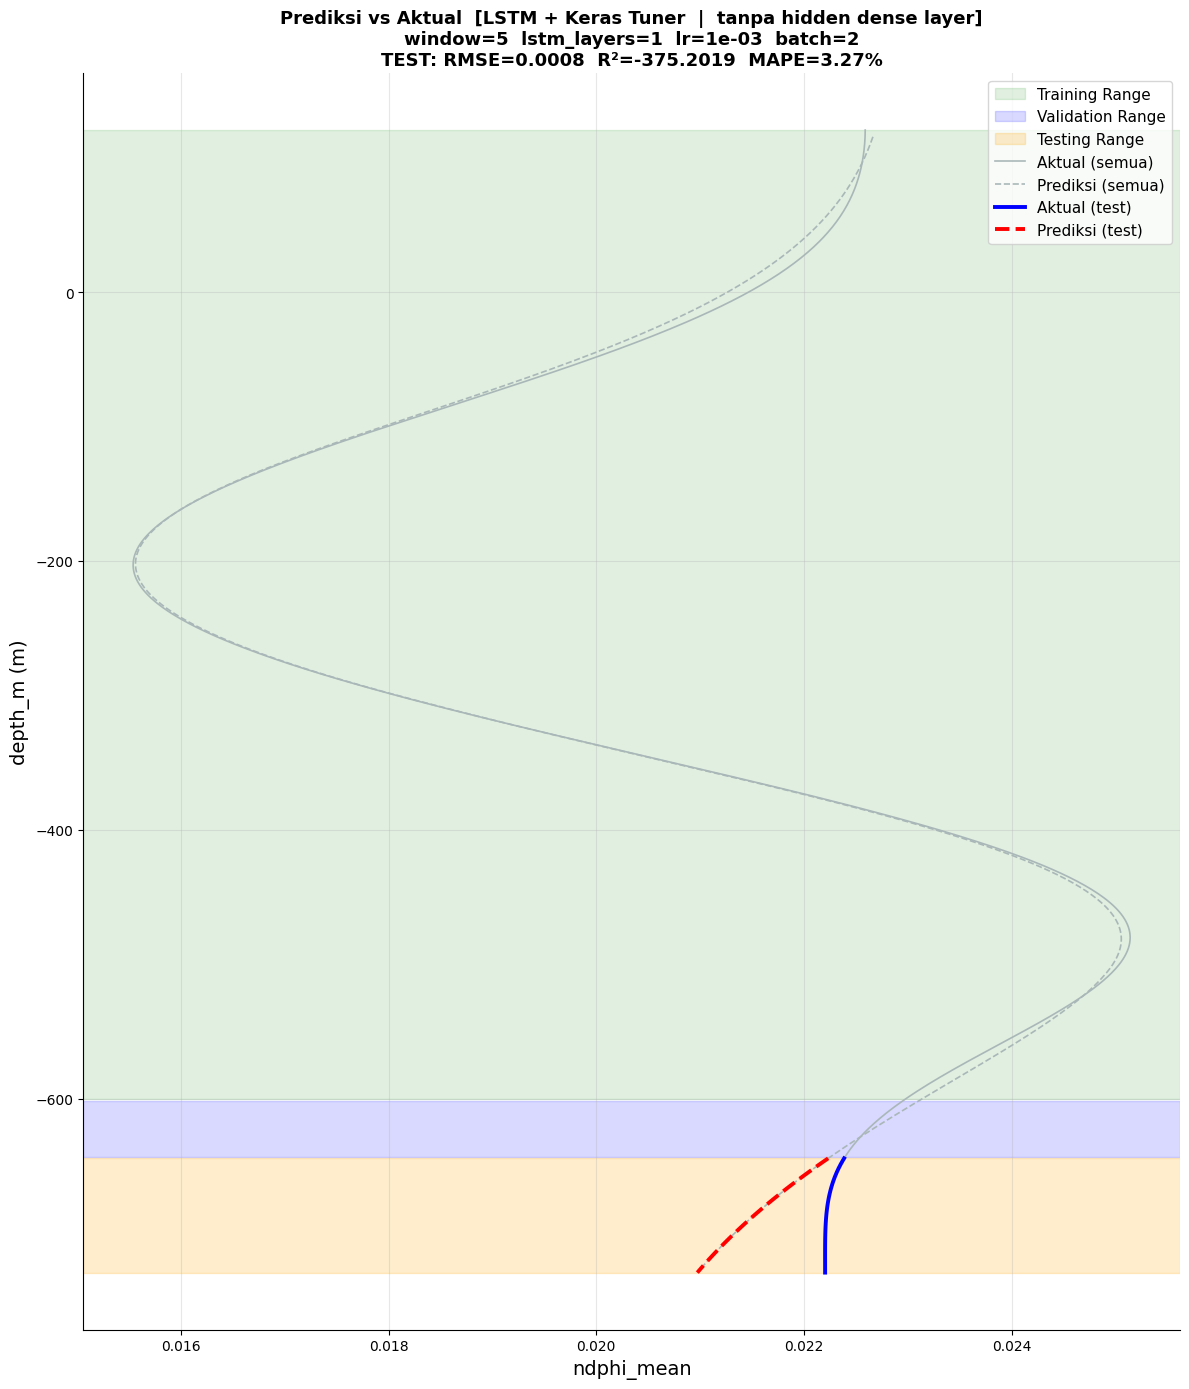

  Disimpan → depth_based_prediction_lstm_tuned.png

  [2/3] Membuat training history plot ...
  [SKIP] File history tidak ditemukan: training_history_lstm.pkl
  Tambahkan kode berikut di akhir training untuk menyimpan history:

    import joblib
    joblib.dump(history.history, 'training_history_lstm.pkl')

  [3/3] Membuat scatter plot ...


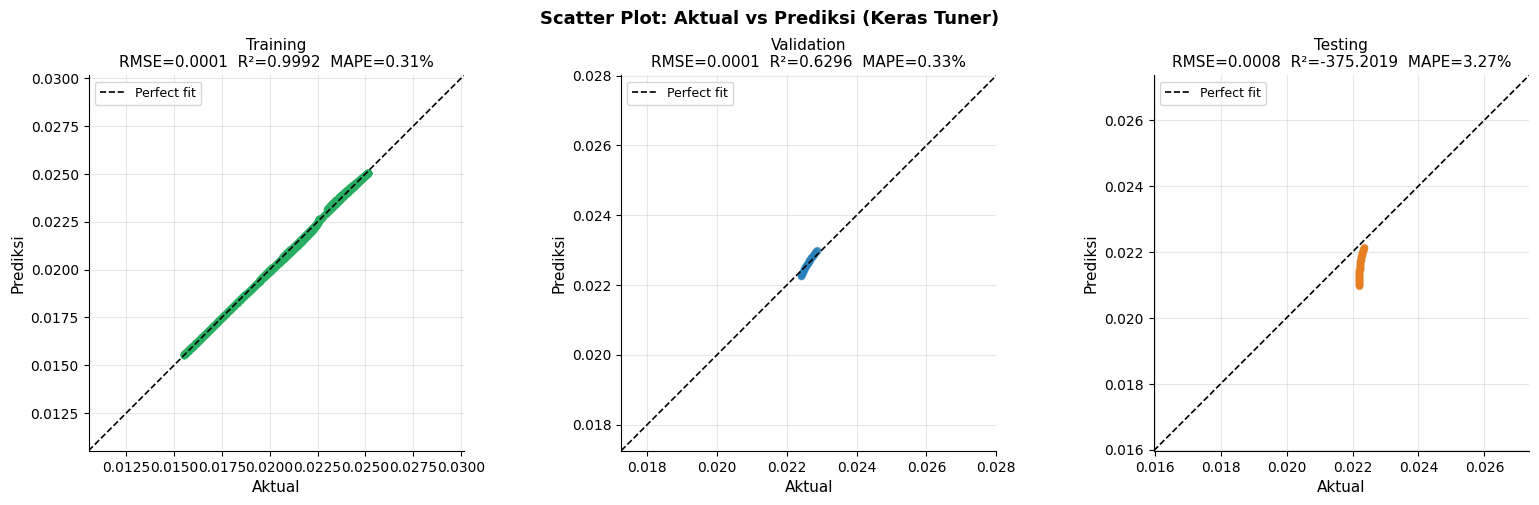

  Disimpan → scatter_lstm_tuned.png

  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)
  Best HP : window=5  lstm_layers=1  lr=1e-03  batch=2
  Metrik                     Training   Validation         TEST      Overall
--------------------------------------------------------------------------------
  RMSE                         0.0001       0.0001       0.0008       0.0003
  R² Score                     0.9992       0.6296    -375.2019       0.9925
  MAPE (%)                       0.31         0.33         3.27         0.60
--------------------------------------------------------------------------------
  Data Points (valid)             717           38           81          846
  RRMSE Overall (%)                                                     1.23
  >>> TEST: RMSE=0.0008  R²=-375.2019  MAPE=3.27%  <<<

  Semua plot berhasil dibuat!
    → depth_based_prediction_lstm_tuned.png
    → training_history_lstm_tuned.png  (jika history tersedia)
    → scatter_lstm_tuned.pn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import math, os, joblib

# =============================================================================
# CONSTANTS  (harus sama persis dengan kode training)
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# FILE PATHS  (sesuaikan jika nama file berbeda)
# =============================================================================
CSV_FILE       = 'resampled_1m_78B_AT90(ohm.m)_78.csv'
MODEL_FILE     = 'model_A_lstm_tuned.keras'
SCALER_X_PATH  = 'scaler_X_A_lstm_tuned.pkl'
SCALER_Y_PATH  = 'scaler_Y_A_lstm_tuned.pkl'
BEST_HP_PATH   = 'best_hp_lstm.pkl'
HISTORY_PATH   = 'training_history_lstm.pkl'   # opsional, jika disimpan

# =============================================================================
# OUTPUT FILENAMES
# =============================================================================
OUT_DEPTH   = 'depth_based_prediction_lstm_tuned.png'
OUT_HISTORY = 'training_history_lstm_tuned.png'
OUT_SCATTER = 'scatter_lstm_tuned.png'

# =============================================================================
# SPLIT PERCENTAGES  (harus sama dengan kode training)
# =============================================================================
TRAIN_PERC = 0.85
VAL_PERC   = 0.05
TEST_PERC  = 0.10

# =============================================================================
# HELPER: create sequences
# =============================================================================
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

# =============================================================================
# HELPER: predict aligned (NaN untuk window awal)
# =============================================================================
def predict_all_aligned(X_raw, scaler_X, scaler_y, model, window_size):
    X_sc  = scaler_X.transform(X_raw)
    seqs  = np.array([X_sc[i : i + window_size]
                      for i in range(len(X_sc) - window_size)])
    preds = scaler_y.inverse_transform(
        model.predict(seqs, verbose=0)).flatten()
    return np.concatenate([np.full(window_size, np.nan), preds])

# =============================================================================
# HELPER: predict per split
# =============================================================================
def predict_split(X_raw, y_raw, scaler_X, scaler_y, model, window_size):
    X_sc  = scaler_X.transform(X_raw)
    y_sc  = scaler_y.transform(y_raw)
    Xs, _ = create_sequences(X_sc, y_sc, window_size)
    y_pred = scaler_y.inverse_transform(
        model.predict(Xs, verbose=0)).flatten()
    y_true = y_raw[window_size:].flatten()
    return y_true, y_pred

# =============================================================================
# HELPER: metrics
# =============================================================================
def eval_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape

# =============================================================================
# HELPER: label per baris
# =============================================================================
def assign_data_type(z, test_limit, train_limit):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'

# =============================================================================
# MATPLOTLIB STYLE GLOBAL
# =============================================================================
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linestyle'  : '-',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

# =============================================================================
# 1) LOAD DATA
# =============================================================================
print("="*60)
print("  MEMUAT DATA ...")
print("="*60)

data = pd.read_csv(CSV_FILE, sep=';')
print(f"  Data dimuat: {len(data)} baris\n")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)

min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

test_limit = min_z + z_range * TEST_PERC
test_mask  = data_sorted[DEPTH] <= test_limit

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[~test_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit = train_val_data[DEPTH].max() - train_val_range * (
    TRAIN_PERC / (1 - TEST_PERC))

train_data      = train_val_data[train_val_data[DEPTH] > train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"  Training   : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts)")
print(f"  Validation : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts)")
print(f"  Testing    : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts)\n")

# raw arrays
X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

# =============================================================================
# 2) LOAD MODEL & SCALERS
# =============================================================================
print("="*60)
print("  MEMUAT MODEL & SCALERS ...")
print("="*60)

try:
    from tensorflow.keras.models import load_model
    model    = load_model(MODEL_FILE)
    scaler_X = joblib.load(SCALER_X_PATH)
    scaler_y = joblib.load(SCALER_Y_PATH)
    best_hp  = joblib.load(BEST_HP_PATH)
    WINDOW_SIZE = best_hp['window_size']
    print(f"  Model      : {MODEL_FILE}")
    print(f"  window_size: {WINDOW_SIZE}")
    print(f"  lstm_layers: {best_hp.get('num_lstm_layers')}")
    print(f"  lr         : {best_hp.get('learning_rate'):.0e}")
    print(f"  batch_size : {best_hp.get('batch_size')}\n")
except Exception as e:
    raise RuntimeError(f"Gagal memuat model/scaler: {e}")

# =============================================================================
# 3) GENERATE PREDICTIONS
# =============================================================================
print("="*60)
print("  MEMBUAT PREDIKSI ...")
print("="*60)

y_true_train, y_pred_train = predict_split(
    X_train_raw, y_train_raw, scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_val,   y_pred_val   = predict_split(
    X_val_raw,   y_val_raw,   scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_test,  y_pred_test  = predict_split(
    X_test_raw,  y_test_raw,  scaler_X, scaler_y, model, WINDOW_SIZE)

all_preds = predict_all_aligned(
    data_sorted[[RES, DEPTH]].values, scaler_X, scaler_y, model, WINDOW_SIZE)

valid_mask  = ~np.isnan(all_preds)
y_true_all  = data_sorted[PHI].values[valid_mask]
y_pred_all  = all_preds[valid_mask]

# metrics
rmse_train, r2_train, mape_train = eval_metrics(y_true_train, y_pred_train)
rmse_val,   r2_val,   mape_val   = eval_metrics(y_true_val,   y_pred_val)
rmse_test,  r2_test,  mape_test  = eval_metrics(y_true_test,  y_pred_test)
rmse_overall, r2_overall, mape_overall = eval_metrics(y_true_all, y_pred_all)
rrmse_overall = np.sqrt(np.sum((y_true_all - y_pred_all)**2) /
                        (np.sum(y_true_all**2) + EPS)) * 100

# labeling
data_sorted[TYPE_COL]  = data_sorted[DEPTH].apply(
    lambda z: assign_data_type(z, test_limit, train_limit))
data_sorted[PHI_PRED]  = all_preds
data_sorted[ERR_COL]   = (
    np.abs(data_sorted[PHI].values - all_preds) /
    (np.abs(data_sorted[PHI].values) + EPS)
) * 100

train_sc = data_sorted[data_sorted[TYPE_COL] == 'Training']
val_sc   = data_sorted[data_sorted[TYPE_COL] == 'Validation']
test_sc  = data_sorted[data_sorted[TYPE_COL] == 'Testing']

print(f"  Training   → RMSE={rmse_train:.4f}  R²={r2_train:.4f}  MAPE={mape_train:.2f}%")
print(f"  Validation → RMSE={rmse_val:.4f}  R²={r2_val:.4f}  MAPE={mape_val:.2f}%")
print(f"  Testing    → RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%")
print(f"  Overall    → RMSE={rmse_overall:.4f}  R²={r2_overall:.4f}  MAPE={mape_overall:.2f}%\n")

# =============================================================================
# PLOT 1: DEPTH PROFILE
# =============================================================================
print("  [1/3] Membuat depth profile plot ...")

fig, ax = plt.subplots(figsize=(12, 14))

train_depths = train_sc[DEPTH]
val_depths   = val_sc[DEPTH]
test_depths  = test_sc[DEPTH]

# background regions
if len(train_depths):
    ax.axhspan(train_depths.min(), train_depths.max(),
               alpha=0.12, color='green',  label='Training Range',   zorder=1)
if len(val_depths):
    ax.axhspan(val_depths.min(),   val_depths.max(),
               alpha=0.15, color='blue',   label='Validation Range', zorder=1)
if len(test_depths):
    ax.axhspan(test_depths.min(),  test_depths.max(),
               alpha=0.20, color='orange', label='Testing Range',    zorder=1)

# overall lines (grey, background)
ax.plot(data_sorted[PHI],      data_sorted[DEPTH],
        '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
ax.plot(data_sorted[PHI_PRED], data_sorted[DEPTH],
        '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)

# test lines (foreground, bold)
ax.plot(test_sc[PHI],      test_sc[DEPTH],
        '-',  color='blue', lw=2.8, label='Aktual (test)',    zorder=4)
ax.plot(test_sc[PHI_PRED], test_sc[DEPTH],
        '--', color='red',  lw=2.8, label='Prediksi (test)',  zorder=4)

ax.set_xlabel(PHI, fontsize=14)
ax.set_ylabel(f'{DEPTH} (m)', fontsize=14)
ax.set_title(
    f'Prediksi vs Aktual  [LSTM + Keras Tuner  |  tanpa hidden dense layer]\n'
    f'window={WINDOW_SIZE}  '
    f'lstm_layers={best_hp.get("num_lstm_layers")}  '
    f'lr={best_hp.get("learning_rate"):.0e}  '
    f'batch={best_hp.get("batch_size")}\n'
    f'TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%',
    fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DEPTH, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_DEPTH}\n")

# =============================================================================
# PLOT 2: TRAINING HISTORY  (butuh file history)
# =============================================================================
print("  [2/3] Membuat training history plot ...")

if os.path.exists(HISTORY_PATH):
    history_data = joblib.load(HISTORY_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history_data['loss'],     color='#2980b9', lw=1.8, label='Train Loss')
    axes[0].plot(history_data['val_loss'], color='#e74c3c', lw=1.8, label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('MSE',   fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history_data['mae'],     color='#2980b9', lw=1.8, label='Train MAE')
    axes[1].plot(history_data['val_mae'], color='#e74c3c', lw=1.8, label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('MAE',   fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — Best HP  '
        f'(window={WINDOW_SIZE}, '
        f'lstm_layers={best_hp.get("num_lstm_layers")}, '
        f'lr={best_hp.get("learning_rate"):.0e}, '
        f'batch={best_hp.get("batch_size")})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_HISTORY, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Disimpan → {OUT_HISTORY}\n")
else:
    print(f"  [SKIP] File history tidak ditemukan: {HISTORY_PATH}")
    print(f"  Tambahkan kode berikut di akhir training untuk menyimpan history:\n")
    print(f"    import joblib")
    print(f"    joblib.dump(history.history, '{HISTORY_PATH}')\n")

# =============================================================================
# PLOT 3: SCATTER PLOT
# =============================================================================
print("  [3/3] Membuat scatter plot ...")

splits = [
    ('Training',   y_true_train, y_pred_train, '#27ae60', rmse_train, r2_train, mape_train),
    ('Validation', y_true_val,   y_pred_val,   '#2980b9', rmse_val,   r2_val,   mape_val),
    ('Testing',    y_true_test,  y_pred_test,  '#e67e22', rmse_test,  r2_test,  mape_test),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20, zorder=3)

    # garis perfect fit
    lims = [min(yt.min(), yp.min()) - 0.005,
            max(yt.max(), yp.max()) + 0.005]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit', zorder=4)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    ax.set_xlabel('Aktual',   fontsize=11)
    ax.set_ylabel('Prediksi', fontsize=11)
    ax.set_title(
        f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%',
        fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle(
    'Scatter Plot: Aktual vs Prediksi (Keras Tuner)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SCATTER}\n")

# =============================================================================
# SUMMARY
# =============================================================================
W = 80
print("=" * W)
print(f"  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)")
print(f"  Best HP : window={WINDOW_SIZE}"
      f"  lstm_layers={best_hp.get('num_lstm_layers')}"
      f"  lr={best_hp.get('learning_rate'):.0e}"
      f"  batch={best_hp.get('batch_size')}")
print("=" * W)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W)
print(f"  {'RMSE':<22} {rmse_train:>12.4f} {rmse_val:>12.4f} {rmse_test:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_train:>12.2f} {mape_val:>12.2f} {mape_test:>12.2f} {mape_overall:>12.2f}")
print("-" * W)
print(f"  {'Data Points (valid)':<22} {len(y_true_train):>12} {len(y_true_val):>12} {len(y_true_test):>12} {valid_mask.sum():>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W)
print(f"  >>> TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%  <<<")
print("=" * W)
print("\n  Semua plot berhasil dibuat!")
print(f"    → {OUT_DEPTH}")
print(f"    → {OUT_HISTORY}  (jika history tersedia)")
print(f"    → {OUT_SCATTER}")

  MEMUAT DATA ...
  Data dimuat: 851 baris

  Training   : 120.51m – -600.49m  (722 pts)
  Validation : -601.49m – -643.49m  (43 pts)
  Testing    : -644.49m – -729.49m  (86 pts)

  MEMUAT MODEL & SCALERS ...
  Model      : model_A_lstm_tuned.keras
  window_size: 5
  lstm_layers: 1
  lr         : 1e-03
  batch_size : 2

  MEMBUAT PREDIKSI ...

  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)
  Best HP : window=5  lstm_layers=1  lr=1e-03  batch=2
  Metrik                     Training   Validation         TEST      Overall
--------------------------------------------------------------------------------
  RMSE                         0.0001       0.0001       0.0008       0.0003
  R² Score                     0.9992       0.6296    -375.2019       0.9925
  MAPE (%)                       0.31         0.33         3.27         0.60
--------------------------------------------------------------------------------
  Data Points (valid)             717           38           81  

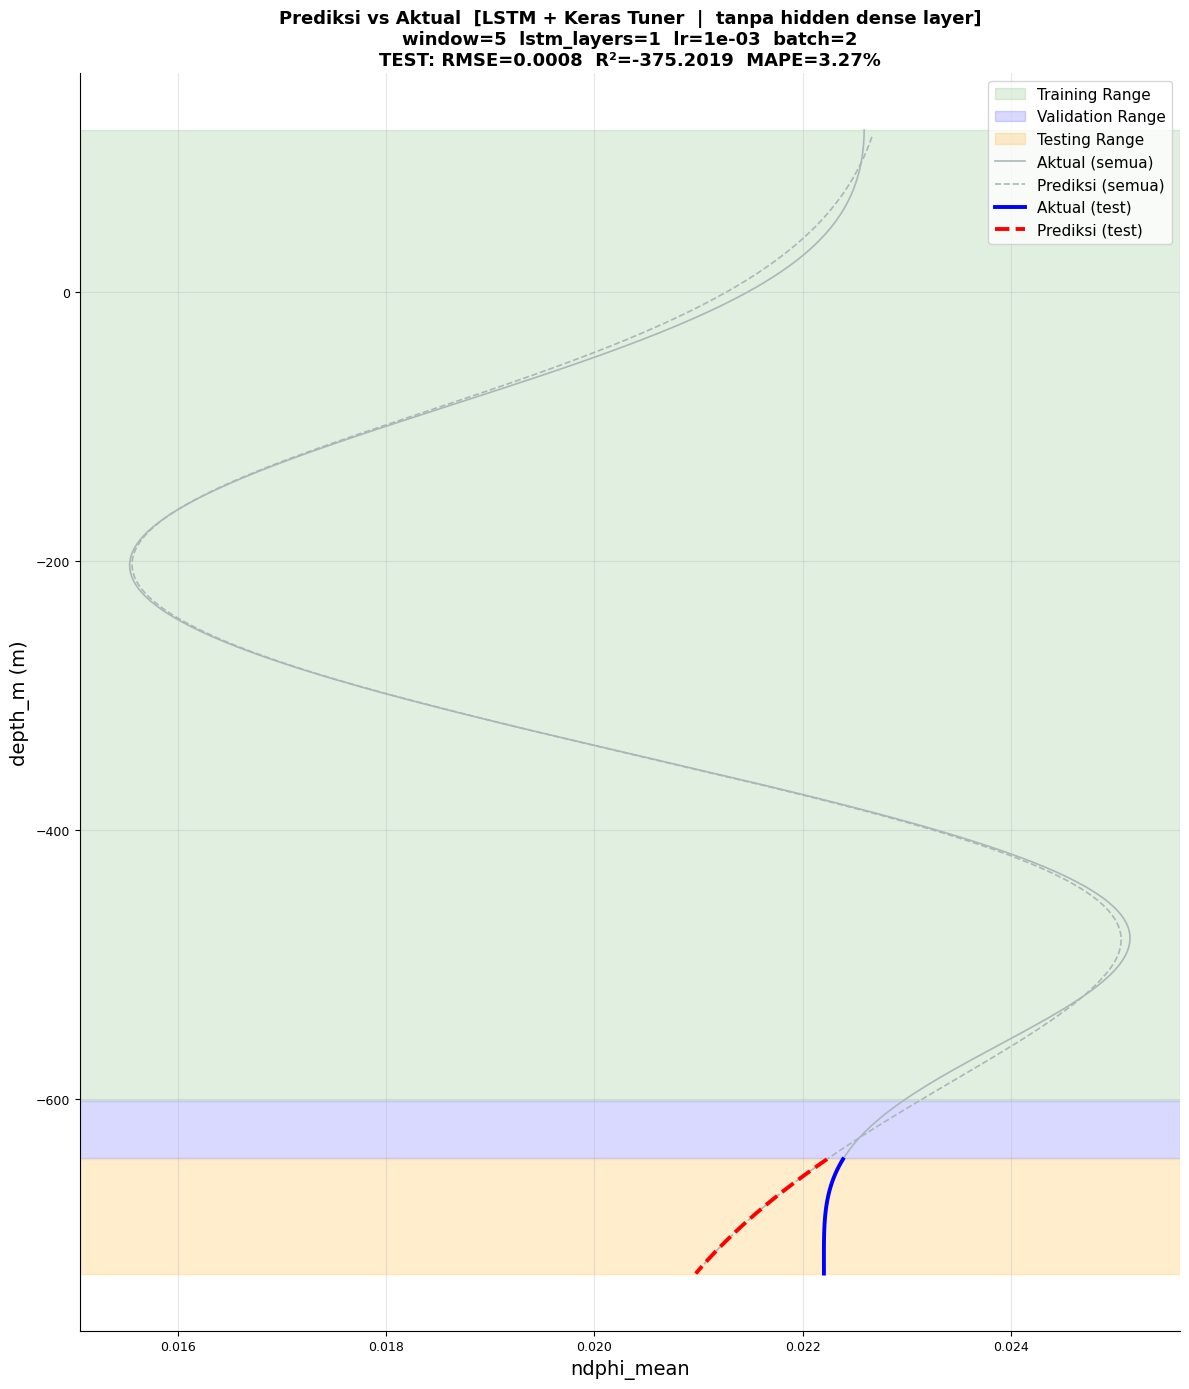

  Disimpan → lstm_depth_profile.png

  [SKIP] History tidak ditemukan: training_history_lstm.pkl
  Tambahkan di akhir training:
    import joblib
    joblib.dump(history.history, 'training_history_lstm.pkl')



C:\Users\reyza\AppData\Local\Temp\ipykernel_19372\1859260128.py:375: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3)
C:\Users\reyza\AppData\Local\Temp\ipykernel_19372\1859260128.py:387: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3)
C:\Users\reyza\AppData\Local\Temp\ipykernel_19372\1859260128.py:402: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.grid(True, alpha=0.3)


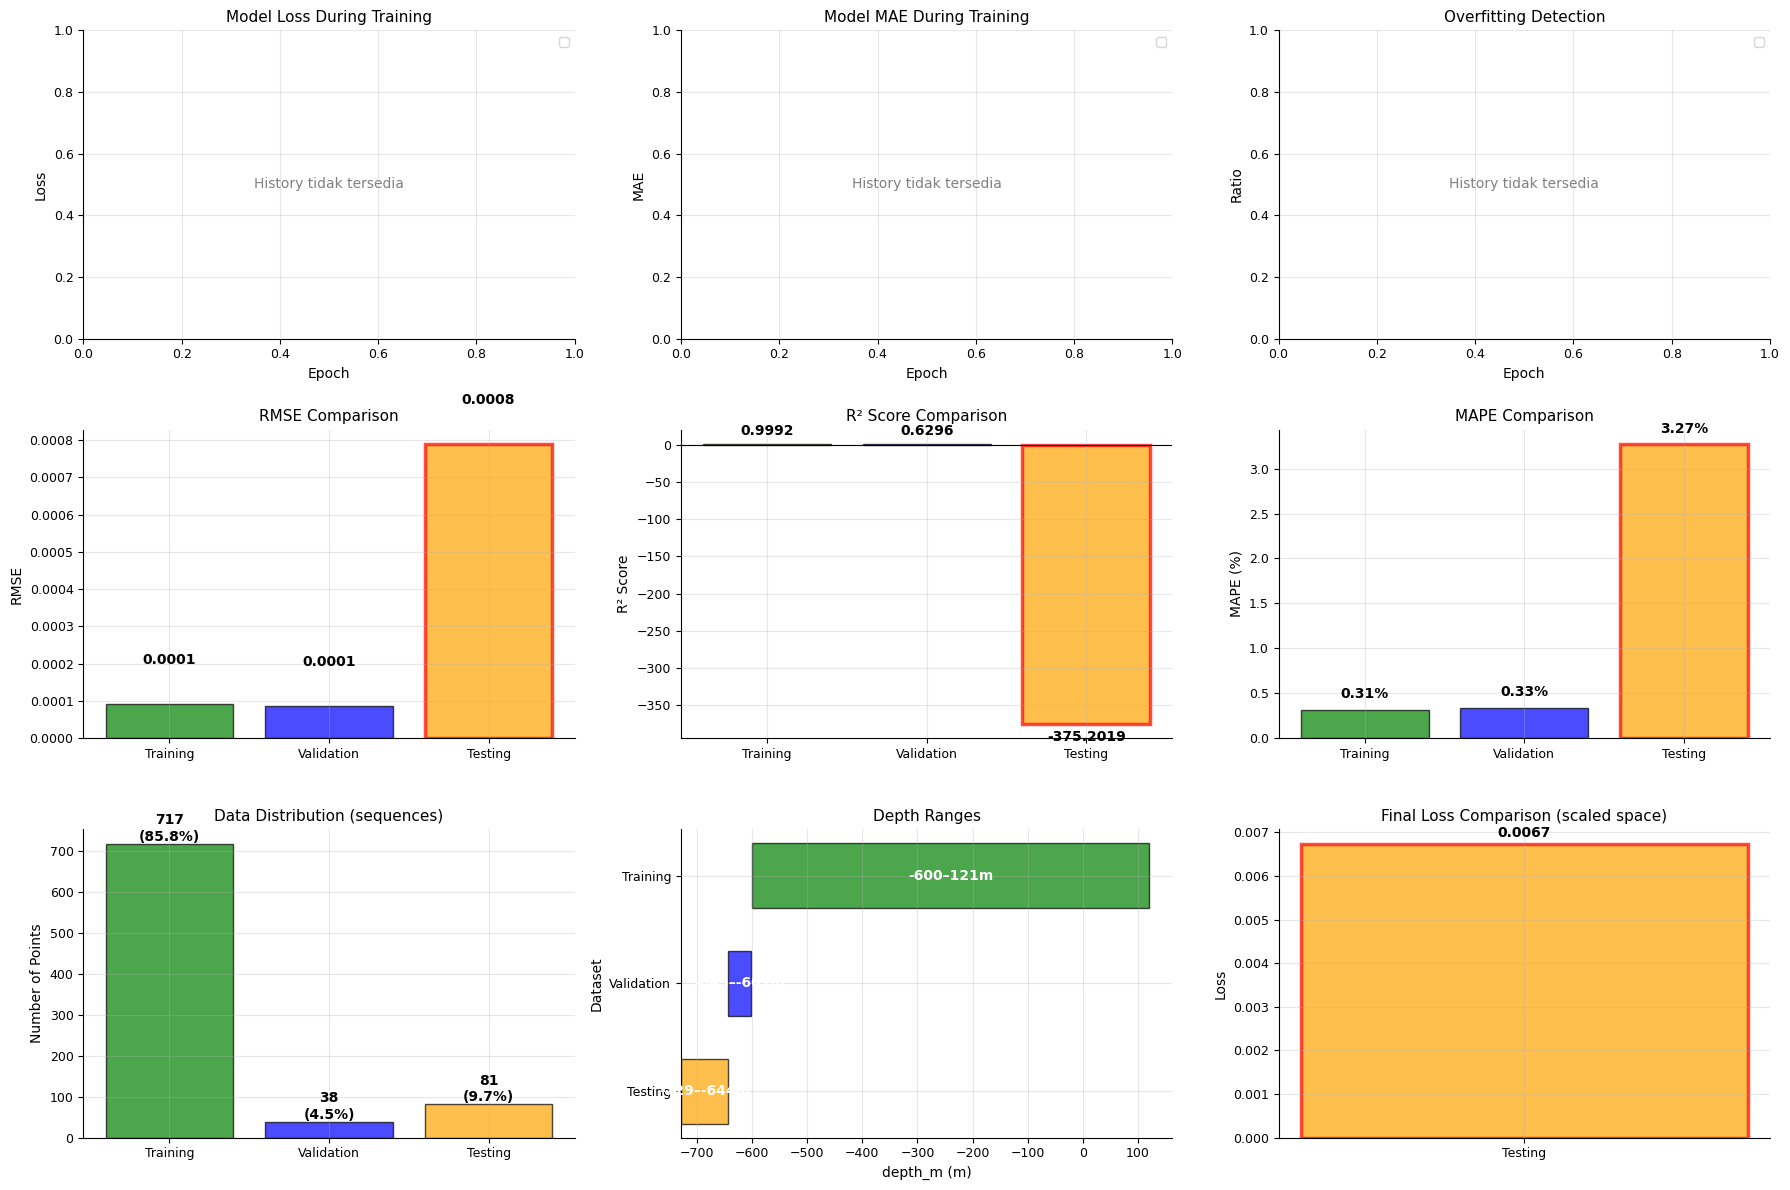

  Disimpan → lstm_comprehensive_analysis.png



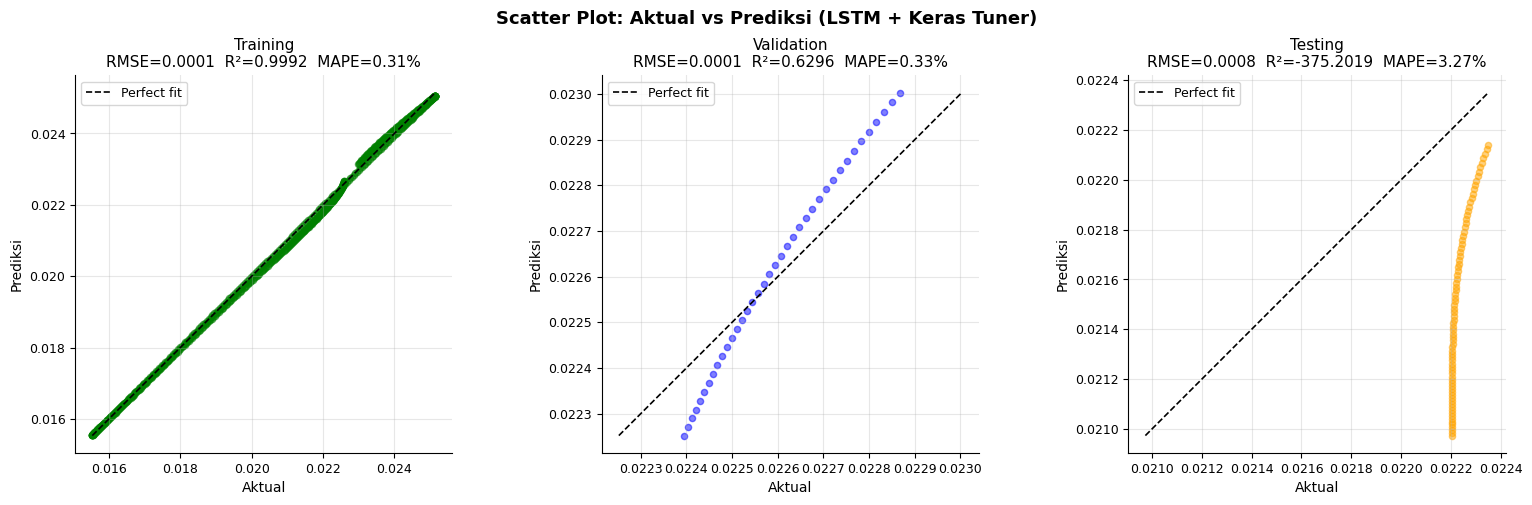

  Disimpan → lstm_scatter.png



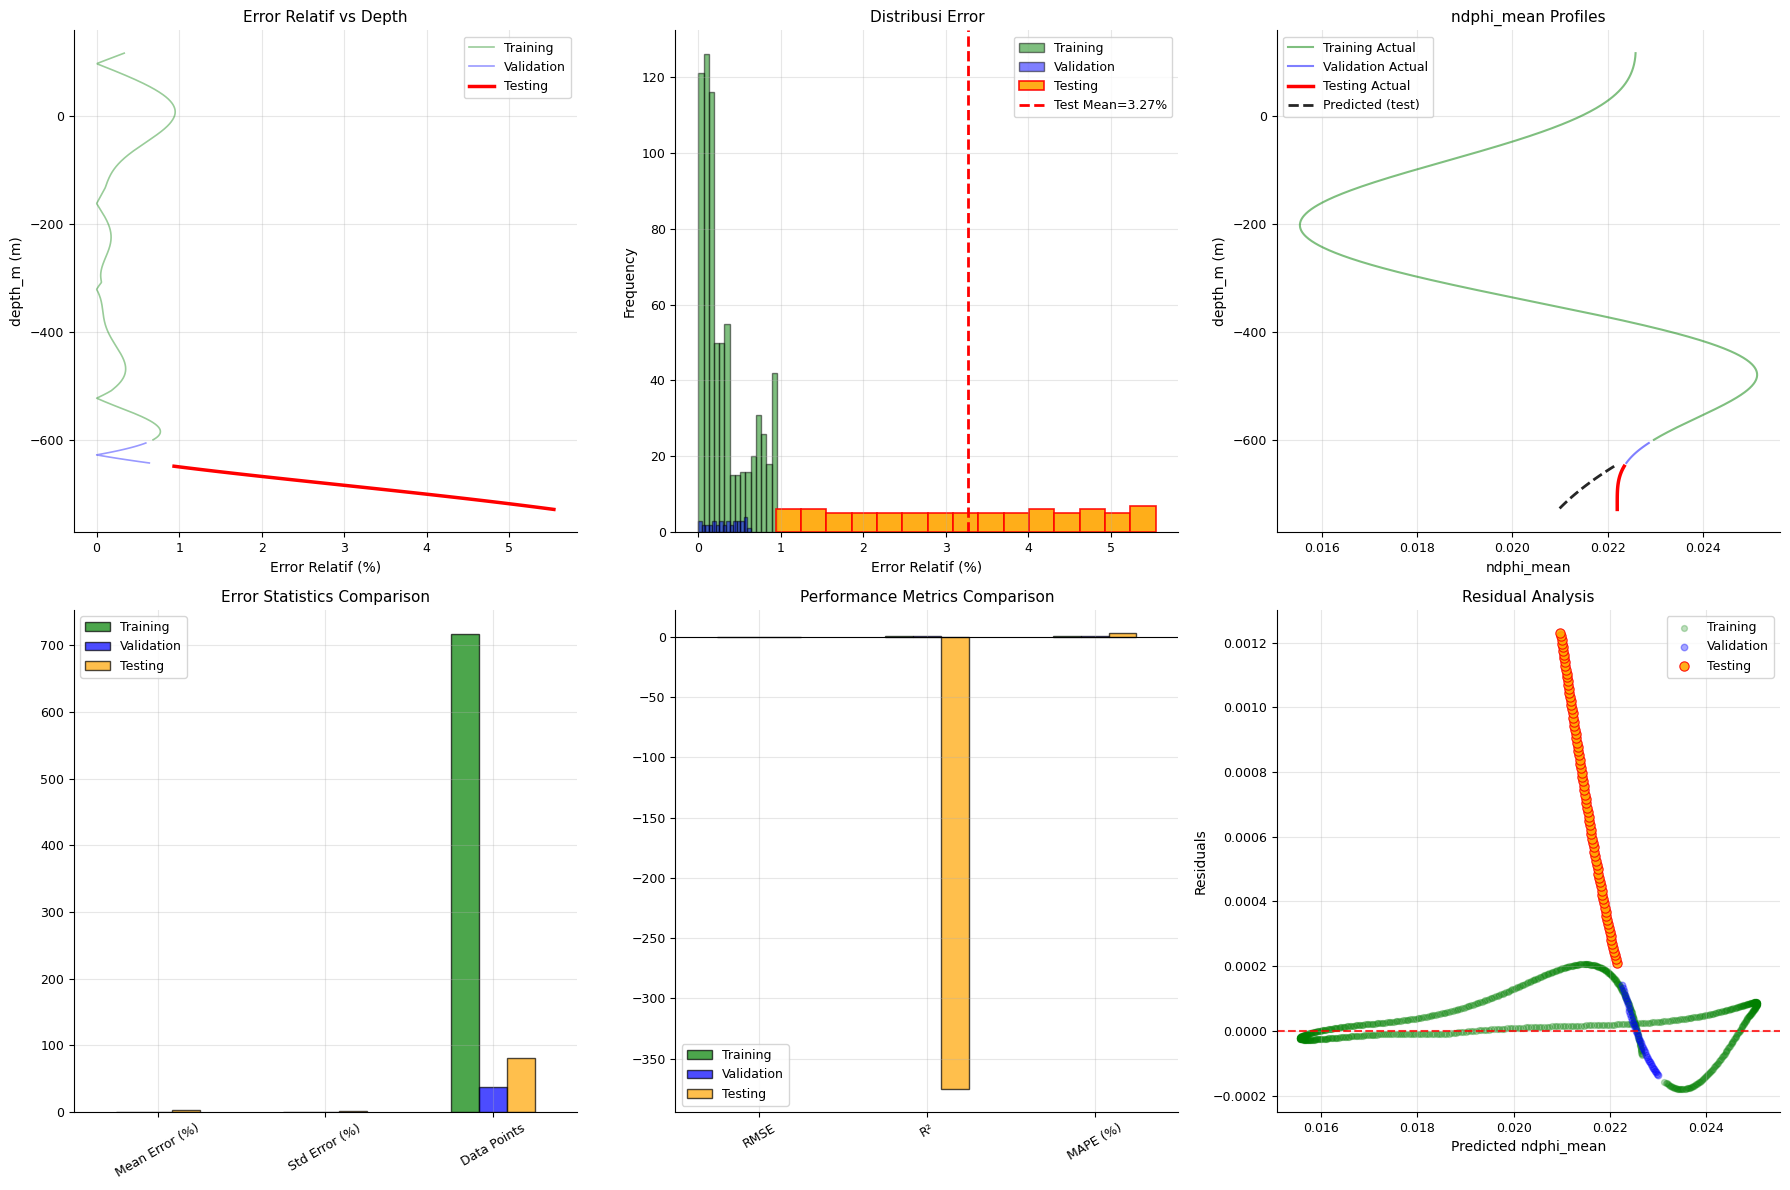

  Disimpan → lstm_error_analysis.png



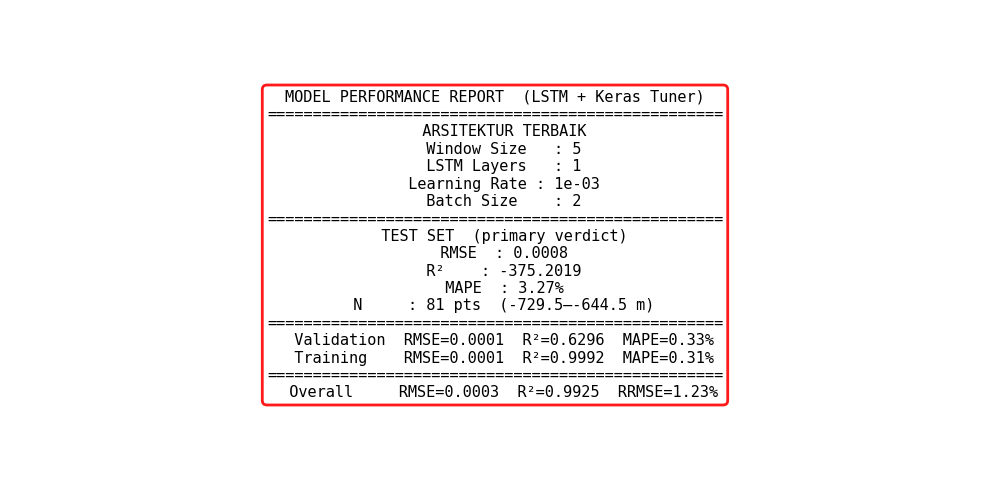

  Disimpan → lstm_metrics_summary.png

  File disimpan → lstm_predictions.csv

  Semua output berhasil dibuat!
    → lstm_depth_profile.png
    → lstm_training_history.png  (jika history tersedia)
    → lstm_comprehensive_analysis.png
    → lstm_scatter.png
    → lstm_error_analysis.png
    → lstm_metrics_summary.png
    → lstm_predictions.csv



In [9]:
# =============================================================================
#  ERROR ANALYSIS & METRIC SUMMARY — LSTM Porosity Prediction
#  Utah FORGE Site | Sumur FORGE 78B-32
#  Target   : ndphi_mean (effective porosity)
#  Features : mt_res_ohmm + depth_m
#  Split    : depth-based  85 / 5 / 10  (train / val / test)
# =============================================================================
#
#  CARA PENGGUNAAN:
#  Jalankan sebagai STANDALONE script / notebook cell.
#  Semua data & model diload ulang dari file.
#
#  FILE YANG DIBUTUHKAN (letakkan di direktori kerja yang sama):
#    - resampled_1m_78B_AT90(ohm.m)_78.csv
#    - model_A_lstm_tuned.keras
#    - scaler_X_A_lstm_tuned.pkl
#    - scaler_Y_A_lstm_tuned.pkl
#    - best_hp_lstm.pkl
#    - training_history_lstm.pkl   (opsional)
# =============================================================================

import os, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# =============================================================================
# CONSTANTS  — identik dengan kode training
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# FILE PATHS
# =============================================================================
CSV_FILE      = 'resampled_1m_78B_AT90(ohm.m)_78.csv'
MODEL_FILE    = 'model_A_lstm_tuned.keras'
SCALER_X_PATH = 'scaler_X_A_lstm_tuned.pkl'
SCALER_Y_PATH = 'scaler_Y_A_lstm_tuned.pkl'
BEST_HP_PATH  = 'best_hp_lstm.pkl'
HISTORY_PATH  = 'training_history_lstm.pkl'

# =============================================================================
# OUTPUT FILENAMES
# =============================================================================
OUT_COMPREHENSIVE = 'lstm_comprehensive_analysis.png'
OUT_ERROR         = 'lstm_error_analysis.png'
OUT_SUMMARY       = 'lstm_metrics_summary.png'
OUT_SCATTER       = 'lstm_scatter.png'

# =============================================================================
# SPLIT PERCENTAGES  — identik dengan kode training
# =============================================================================
TRAIN_PERC = 0.85
VAL_PERC   = 0.05
TEST_PERC  = 0.10

# =============================================================================
# HELPER FUNCTIONS  — identik dengan kode training
# =============================================================================

def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)


def predict_all_aligned(X_raw, scaler_X, scaler_y, model, window_size):
    """Prediksi seluruh kolom data; NaN untuk window_size baris pertama."""
    X_sc  = scaler_X.transform(X_raw)
    seqs  = np.array([X_sc[i : i + window_size]
                      for i in range(len(X_sc) - window_size)])
    preds = scaler_y.inverse_transform(
        model.predict(seqs, verbose=0)).flatten()
    return np.concatenate([np.full(window_size, np.nan), preds])


def predict_split(X_raw, y_raw, scaler_X, scaler_y, model, window_size):
    """Prediksi per split; return (y_true, y_pred) dalam satuan asli."""
    X_sc   = scaler_X.transform(X_raw)
    y_sc   = scaler_y.transform(y_raw)
    Xs, _  = create_sequences(X_sc, y_sc, window_size)
    y_pred = scaler_y.inverse_transform(
        model.predict(Xs, verbose=0)).flatten()
    y_true = y_raw[window_size:].flatten()
    return y_true, y_pred


def assign_data_type(z, test_limit, train_limit):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'


def eval_metrics(y_true, y_pred):
    """Identik dengan fungsi eval_metrics di kode Siamese."""
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape


# =============================================================================
# 1) LOAD DATA
# =============================================================================
print("=" * 62)
print("  MEMUAT DATA ...")
print("=" * 62)

data = pd.read_csv(CSV_FILE, sep=';')
print(f"  Data dimuat: {len(data)} baris\n")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)

min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

test_limit = min_z + z_range * TEST_PERC
test_mask  = data_sorted[DEPTH] <= test_limit

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[~test_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit     = train_val_data[DEPTH].max() - train_val_range * (
    TRAIN_PERC / (1 - TEST_PERC))

train_data      = train_val_data[train_val_data[DEPTH] >  train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"  Training   : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts)")
print(f"  Validation : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts)")
print(f"  Testing    : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts)\n")

X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

# =============================================================================
# 2) LOAD MODEL & SCALERS
# =============================================================================
print("=" * 62)
print("  MEMUAT MODEL & SCALERS ...")
print("=" * 62)

try:
    from tensorflow.keras.models import load_model
    model    = load_model(MODEL_FILE)
    scaler_X = joblib.load(SCALER_X_PATH)
    scaler_y = joblib.load(SCALER_Y_PATH)
    best_hp  = joblib.load(BEST_HP_PATH)
    WINDOW_SIZE = best_hp['window_size']
    BATCH_SIZE  = best_hp.get('batch_size', '?')
    NUM_LAYERS  = best_hp.get('num_lstm_layers', '?')
    LR          = best_hp.get('learning_rate', float('nan'))
    print(f"  Model      : {MODEL_FILE}")
    print(f"  window_size: {WINDOW_SIZE}")
    print(f"  lstm_layers: {NUM_LAYERS}")
    print(f"  lr         : {LR:.0e}")
    print(f"  batch_size : {BATCH_SIZE}\n")
except Exception as e:
    raise RuntimeError(f"Gagal memuat model/scaler: {e}")

# =============================================================================
# 3) PREDIKSI
# =============================================================================
print("=" * 62)
print("  MEMBUAT PREDIKSI ...")
print("=" * 62)

yt_train, yp_train = predict_split(
    X_train_raw, y_train_raw, scaler_X, scaler_y, model, WINDOW_SIZE)
yt_val,   yp_val   = predict_split(
    X_val_raw,   y_val_raw,   scaler_X, scaler_y, model, WINDOW_SIZE)
yt_test,  yp_test  = predict_split(
    X_test_raw,  y_test_raw,  scaler_X, scaler_y, model, WINDOW_SIZE)

all_preds  = predict_all_aligned(
    data_sorted[[RES, DEPTH]].values, scaler_X, scaler_y, model, WINDOW_SIZE)

valid_mask = ~np.isnan(all_preds)
y_true_all = data_sorted[PHI].values[valid_mask]
y_pred_all = all_preds[valid_mask]

data_sorted[TYPE_COL] = data_sorted[DEPTH].apply(
    lambda z: assign_data_type(z, test_limit, train_limit))
data_sorted[PHI_PRED] = all_preds
data_sorted[ERR_COL]  = (
    np.abs(data_sorted[PHI].values - all_preds) /
    (np.abs(data_sorted[PHI].values) + EPS)) * 100

train_sc = data_sorted[data_sorted[TYPE_COL] == 'Training']
val_sc   = data_sorted[data_sorted[TYPE_COL] == 'Validation']
test_sc  = data_sorted[data_sorted[TYPE_COL] == 'Testing']

# =============================================================================
# 4) METRICS  — identik dengan kode Siamese
# =============================================================================
rmse_tr, r2_tr, mape_tr = eval_metrics(yt_train, yp_train)
rmse_v,  r2_v,  mape_v  = eval_metrics(yt_val,   yp_val)
rmse_te, r2_te, mape_te = eval_metrics(yt_test,  yp_test)

all_yt = np.concatenate([yt_train, yt_val, yt_test])
all_yp = np.concatenate([yp_train, yp_val, yp_test])
rmse_overall, r2_overall, mape_overall = eval_metrics(all_yt, all_yp)
rrmse_overall = np.sqrt(np.sum((all_yt - all_yp)**2) /
                        (np.sum(all_yt**2) + EPS)) * 100

# =============================================================================
# 5) DEPTH SEQUENCES  (offset = WINDOW_SIZE)
# =============================================================================
W = WINDOW_SIZE
depth_train_seq = train_data[DEPTH].values[W:]
depth_val_seq   = validation_data[DEPTH].values[W:]
depth_test_seq  = test_data[DEPTH].values[W:]

train_d_min = train_data[DEPTH].min()
train_d_max = train_data[DEPTH].max()
val_d_min   = validation_data[DEPTH].min()
val_d_max   = validation_data[DEPTH].max()
test_d_min  = test_data[DEPTH].min()
test_d_max  = test_data[DEPTH].max()

# Relative error arrays (persen)
err_train = np.abs(yt_train - yp_train) / (np.abs(yt_train) + EPS) * 100
err_val   = np.abs(yt_val   - yp_val)   / (np.abs(yt_val)   + EPS) * 100
err_test  = np.abs(yt_test  - yp_test)  / (np.abs(yt_test)  + EPS) * 100

# Residuals
res_train = yt_train - yp_train
res_val   = yt_val   - yp_val
res_test  = yt_test  - yp_test

# =============================================================================
# 6) PRINT RESULTS  — identik format dengan kode Siamese
# =============================================================================
W_line = 80
print("\n" + "=" * W_line)
print(f"  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)")
print(f"  Best HP : window={WINDOW_SIZE}  "
      f"lstm_layers={NUM_LAYERS}  "
      f"lr={LR:.0e}  "
      f"batch={BATCH_SIZE}")
print("=" * W_line)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W_line)
print(f"  {'RMSE':<22} {rmse_tr:>12.4f} {rmse_v:>12.4f} {rmse_te:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_tr:>12.4f} {r2_v:>12.4f} {r2_te:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_tr:>12.2f} {mape_v:>12.2f} {mape_te:>12.2f} {mape_overall:>12.2f}")
print("-" * W_line)
print(f"  {'Data Points (valid)':<22} {len(yt_train):>12} {len(yt_val):>12} {len(yt_test):>12} {valid_mask.sum():>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W_line)
print(f"  >>> TEST: RMSE={rmse_te:.4f}  R²={r2_te:.4f}  MAPE={mape_te:.2f}%  <<<")
print("=" * W_line)

# =============================================================================
# PLOT 1: DEPTH PROFILE  — identik dengan siamese section 14
# =============================================================================
plt.figure(figsize=(12, 14))

plt.axhspan(train_d_min, train_d_max, alpha=0.12, color='green',
            label='Training Range',   zorder=1)
plt.axhspan(val_d_min,   val_d_max,   alpha=0.15, color='blue',
            label='Validation Range', zorder=1)
plt.axhspan(test_d_min,  test_d_max,  alpha=0.20, color='orange',
            label='Testing Range',    zorder=1)

plt.plot(data_sorted[PHI],      data_sorted[DEPTH],
         '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH],
         '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)

plt.plot(test_sc[PHI],      test_sc[DEPTH],
         '-',  color='blue', lw=2.8, label='Aktual (test)',   zorder=4)
plt.plot(test_sc[PHI_PRED], test_sc[DEPTH],
         '--', color='red',  lw=2.8, label='Prediksi (test)', zorder=4)

plt.xlabel(PHI, fontsize=14)
plt.ylabel(f'{DEPTH} (m)', fontsize=14)
plt.title(
    f'Prediksi vs Aktual  [LSTM + Keras Tuner  |  tanpa hidden dense layer]\n'
    f'window={WINDOW_SIZE}  '
    f'lstm_layers={NUM_LAYERS}  '
    f'lr={LR:.0e}  '
    f'batch={BATCH_SIZE}\n'
    f'TEST: RMSE={rmse_te:.4f}  R²={r2_te:.4f}  MAPE={mape_te:.2f}%',
    fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_depth_profile.png', dpi=300, bbox_inches='tight')
plt.show()
print("  Disimpan → lstm_depth_profile.png\n")

# =============================================================================
# PLOT 2: TRAINING HISTORY  — identik dengan siamese section 15
# =============================================================================
if os.path.exists(HISTORY_PATH):
    hist = joblib.load(HISTORY_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist['loss'],     label='Train Loss')
    axes[0].plot(hist['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    mae_key  = 'mae'     if 'mae'     in hist else [k for k in hist if 'mae' in k and 'val' not in k][0]
    vmae_key = 'val_mae' if 'val_mae' in hist else [k for k in hist if 'val' in k and 'mae' in k][0]
    axes[1].plot(hist[mae_key],  label='Train MAE')
    axes[1].plot(hist[vmae_key], label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — LSTM + Keras Tuner  '
        f'(window={WINDOW_SIZE}, '
        f'lstm_layers={NUM_LAYERS}, '
        f'lr={LR:.0e}, '
        f'batch={BATCH_SIZE})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("  Disimpan → lstm_training_history.png\n")
else:
    print(f"  [SKIP] History tidak ditemukan: {HISTORY_PATH}")
    print(f"  Tambahkan di akhir training:\n"
          f"    import joblib\n"
          f"    joblib.dump(history.history, '{HISTORY_PATH}')\n")

# =============================================================================
# PLOT 3: COMPREHENSIVE ANALYSIS (3×3)
# — identik struktur dengan siamese section 16
# =============================================================================
datasets   = ['Training', 'Validation', 'Testing']
colors_bar = ['green', 'blue', 'orange']

plt.figure(figsize=(18, 12))

# ── Loss curve ──────────────────────────────────────────────────────────────
plt.subplot(3, 3, 1)
if os.path.exists(HISTORY_PATH):
    hist = joblib.load(HISTORY_PATH)
    plt.plot(hist['loss'],     label='Training Loss',   linewidth=2)
    plt.plot(hist['val_loss'], label='Validation Loss', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model Loss During Training')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

# ── MAE curve ────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 2)
if os.path.exists(HISTORY_PATH):
    plt.plot(hist[mae_key],  label='Training MAE',   linewidth=2)
    plt.plot(hist[vmae_key], label='Validation MAE', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model MAE During Training')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.legend(); plt.grid(True, alpha=0.3)

# ── Overfitting detection ─────────────────────────────────────────────────────
plt.subplot(3, 3, 3)
if os.path.exists(HISTORY_PATH):
    tl = np.array(hist['loss'])
    vl = np.array(hist['val_loss'])
    plt.plot(vl / (tl + EPS), label='Val/Train Loss Ratio',
             linewidth=2, color='purple')
    plt.axhline(y=1.0, color='r', linestyle='--', label='Ratio=1.0', alpha=0.8)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Overfitting Detection')
plt.xlabel('Epoch'); plt.ylabel('Ratio')
plt.legend(); plt.grid(True, alpha=0.3)

# ── RMSE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 4)
rmse_vals = [rmse_tr, rmse_v, rmse_te]
bars = plt.bar(datasets, rmse_vals, color=colors_bar,
               alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('RMSE Comparison'); plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.0001,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# ── R² bar ────────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 5)
r2_vals = [r2_tr, r2_v, r2_te]
bars = plt.bar(datasets, r2_vals, color=colors_bar,
               alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('R² Score Comparison'); plt.ylabel('R² Score')
plt.axhline(0, color='black', lw=0.8)
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, r2_vals):
    offset = abs(max(r2_vals) - min(r2_vals)) * 0.02
    ypos   = v + offset if v >= 0 else v - offset
    va     = 'bottom'  if v >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{v:.4f}', ha='center', va=va, fontweight='bold')

# ── MAPE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 6)
mape_vals = [mape_tr, mape_v, mape_te]
bars = plt.bar(datasets, mape_vals, color=colors_bar,
               alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('MAPE Comparison'); plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, mape_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# ── Data distribution ─────────────────────────────────────────────────────────
plt.subplot(3, 3, 7)
data_counts = [len(yt_train), len(yt_val), len(yt_test)]
total_pts   = sum(data_counts)
bars = plt.bar(datasets, data_counts, color=colors_bar,
               alpha=0.7, edgecolor='black')
plt.title('Data Distribution (sequences)'); plt.ylabel('Number of Points')
plt.grid(True, alpha=0.3)
for bar, cnt in zip(bars, data_counts):
    pct = cnt / (total_pts + EPS) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{cnt}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# ── Depth ranges ──────────────────────────────────────────────────────────────
plt.subplot(3, 3, 8)
depth_ranges = {
    'Training':   [train_d_min, train_d_max],
    'Validation': [val_d_min,   val_d_max],
    'Testing':    [test_d_min,  test_d_max],
}
for i, (name, (d_min, d_max)) in enumerate(depth_ranges.items()):
    if np.isfinite(d_min) and np.isfinite(d_max):
        plt.barh(i, d_max - d_min, left=d_min, height=0.6,
                 color=colors_bar[i], alpha=0.7, edgecolor='black')
        plt.text(d_min + (d_max - d_min) / 2, i,
                 f'{d_min:.0f}–{d_max:.0f}m',
                 ha='center', va='center', fontweight='bold', color='white')
plt.xlabel(f'{DEPTH} (m)'); plt.ylabel('Dataset')
plt.title('Depth Ranges')
plt.yticks(range(3), list(depth_ranges.keys()))
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()

# ── Final loss comparison (scaled space) ──────────────────────────────────────
plt.subplot(3, 3, 9)
if os.path.exists(HISTORY_PATH):
    final_train_loss = hist['loss'][-1]
    final_val_loss   = hist['val_loss'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss   = float('nan')

# Test loss dalam scaled space
y_test_sc  = scaler_y.transform(y_test_raw)[W:].flatten()
yp_test_sc_raw = model.predict(
    np.array([scaler_X.transform(X_test_raw)[i : i + W]
              for i in range(len(X_test_raw) - W)]),
    verbose=0).flatten()
final_test_loss = float(np.mean((y_test_sc - yp_test_sc_raw) ** 2))

loss_vals  = [final_train_loss, final_val_loss, final_test_loss]
bars = plt.bar(datasets, loss_vals, color=colors_bar,
               alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('Final Loss Comparison (scaled space)')
plt.ylabel('Loss'); plt.grid(True, alpha=0.3)
for bar, v in zip(bars, loss_vals):
    if np.isfinite(v):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(x for x in loss_vals if np.isfinite(x)) * 0.015,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_COMPREHENSIVE, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_COMPREHENSIVE}\n")

# =============================================================================
# PLOT 4: SCATTER PLOT  — identik dengan siamese section 17
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits_sc = [
    ('Training',   yt_train, yp_train, 'green',  rmse_tr, r2_tr, mape_tr),
    ('Validation', yt_val,   yp_val,   'blue',   rmse_v,  r2_v,  mape_v),
    ('Testing',    yt_test,  yp_test,  'orange', rmse_te, r2_te, mape_te),
]
for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits_sc):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(
        f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%',
        fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle(
    'Scatter Plot: Aktual vs Prediksi (LSTM + Keras Tuner)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SCATTER}\n")

# =============================================================================
# PLOT 5: ERROR ANALYSIS (2×3)
# — identik struktur dengan siamese section 18
# =============================================================================
plt.figure(figsize=(18, 12))

# ── Error Relatif vs Depth ────────────────────────────────────────────────────
plt.subplot(2, 3, 1)
plt.plot(err_train, depth_train_seq, 'g-', lw=1.2, label='Training',   alpha=0.4)
plt.plot(err_val,   depth_val_seq,   'b-', lw=1.2, label='Validation', alpha=0.4)
plt.plot(err_test,  depth_test_seq,  'r-', lw=2.5, label='Testing',    alpha=1.0)
plt.xlabel('Error Relatif (%)'); plt.ylabel(f'{DEPTH} (m)')
plt.title('Error Relatif vs Depth')
plt.legend(); plt.grid(True)

# ── Distribusi Error ──────────────────────────────────────────────────────────
plt.subplot(2, 3, 2)
plt.hist(err_train, bins=15, alpha=0.5, color='green',
         label='Training',   edgecolor='black')
plt.hist(err_val,   bins=15, alpha=0.5, color='blue',
         label='Validation', edgecolor='black')
plt.hist(err_test,  bins=15, alpha=0.9, color='orange',
         label='Testing',    edgecolor='red', linewidth=1.2)
plt.axvline(err_test.mean(), color='red', lw=2, linestyle='--',
            label=f'Test Mean={err_test.mean():.2f}%')
plt.xlabel('Error Relatif (%)'); plt.ylabel('Frequency')
plt.title('Distribusi Error')
plt.legend(); plt.grid(True, alpha=0.3)

# ── ndphi_mean Profiles ───────────────────────────────────────────────────────
plt.subplot(2, 3, 3)
plt.plot(yt_train, depth_train_seq, 'g-',  lw=1.5,
         label='Training Actual',   alpha=0.5)
plt.plot(yt_val,   depth_val_seq,   'b-',  lw=1.5,
         label='Validation Actual', alpha=0.5)
plt.plot(yt_test,  depth_test_seq,  'r-',  lw=2.5,
         label='Testing Actual',    alpha=1.0)
plt.plot(yp_test,  depth_test_seq,  'k--', lw=2.0,
         label='Predicted (test)',  alpha=0.85)
plt.xlabel(PHI); plt.ylabel(f'{DEPTH} (m)')
plt.title(f'{PHI} Profiles')
plt.legend(); plt.grid(True)

# ── Error Statistics Comparison ───────────────────────────────────────────────
plt.subplot(2, 3, 4)
stats_data = {
    'Training':   [err_train.mean(), err_train.std(), len(yt_train)],
    'Validation': [err_val.mean(),   err_val.std(),   len(yt_val)],
    'Testing':    [err_test.mean(),  err_test.std(),  len(yt_test)],
}
stats_df = pd.DataFrame(
    stats_data,
    index=['Mean Error (%)', 'Std Error (%)', 'Data Points'])
stats_df.plot(kind='bar', ax=plt.gca(),
              color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Error Statistics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

# ── Performance Metrics Comparison ───────────────────────────────────────────
plt.subplot(2, 3, 5)
metrics_data = {
    'Training':   [rmse_tr, r2_tr, mape_tr],
    'Validation': [rmse_v,  r2_v,  mape_v],
    'Testing':    [rmse_te, r2_te, mape_te],
}
metrics_df = pd.DataFrame(
    metrics_data,
    index=['RMSE', 'R²', 'MAPE (%)'])
metrics_df.plot(kind='bar', ax=plt.gca(),
                color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Performance Metrics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.axhline(0, color='black', lw=0.8)

# ── Residual Analysis ─────────────────────────────────────────────────────────
plt.subplot(2, 3, 6)
plt.scatter(yp_train, res_train, alpha=0.25, color='green',
            label='Training',   s=18)
plt.scatter(yp_val,   res_val,   alpha=0.35, color='blue',
            label='Validation', s=22)
plt.scatter(yp_test,  res_test,  alpha=0.90, color='orange',
            label='Testing',    s=45,
            zorder=4, edgecolors='red', linewidths=0.8)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
plt.xlabel(f'Predicted {PHI}'); plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ERROR, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_ERROR}\n")

# =============================================================================
# PLOT 6: SUMMARY BOX  — identik dengan siamese section 21
# =============================================================================
plt.figure(figsize=(10, 5))
plt.axis('off')

textstr = (
    f"MODEL PERFORMANCE REPORT  (LSTM + Keras Tuner)\n"
    f"{'='*50}\n"
    f"  ARSITEKTUR TERBAIK\n"
    f"  Window Size   : {WINDOW_SIZE}\n"
    f"  LSTM Layers   : {NUM_LAYERS}\n"
    f"  Learning Rate : {LR:.0e}\n"
    f"  Batch Size    : {BATCH_SIZE}\n"
    f"{'='*50}\n"
    f"  TEST SET  (primary verdict)\n"
    f"  RMSE  : {rmse_te:.4f}\n"
    f"  R²    : {r2_te:.4f}\n"
    f"  MAPE  : {mape_te:.2f}%\n"
    f"  N     : {len(yt_test)} pts  ({test_d_min:.1f}–{test_d_max:.1f} m)\n"
    f"{'='*50}\n"
    f"  Validation  RMSE={rmse_v:.4f}  R²={r2_v:.4f}  MAPE={mape_v:.2f}%\n"
    f"  Training    RMSE={rmse_tr:.4f}  R²={r2_tr:.4f}  MAPE={mape_tr:.2f}%\n"
    f"{'='*50}\n"
    f"  Overall     RMSE={rmse_overall:.4f}  R²={r2_overall:.4f}  RRMSE={rrmse_overall:.2f}%"
)

plt.text(0.5, 0.5, textstr, transform=plt.gca().transAxes,
         fontsize=11, va='center', ha='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white',
                   edgecolor='red', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.savefig(OUT_SUMMARY, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SUMMARY}\n")

# =============================================================================
# EXPORT CSV  — identik dengan siamese section 20
# =============================================================================
results_frames = []
for label, df_split, X_raw, y_raw in [
    ('Training',   train_data,      X_train_raw, y_train_raw),
    ('Validation', validation_data, X_val_raw,   y_val_raw),
    ('Testing',    test_data,       X_test_raw,  y_test_raw),
]:
    y_true_v, y_pred_v = predict_split(
        X_raw, y_raw, scaler_X, scaler_y, model, W)
    depth_v = df_split[DEPTH].values[W:]
    frame = pd.DataFrame({
        DEPTH    : depth_v,
        PHI      : y_true_v,
        PHI_PRED : y_pred_v,
        ERR_COL  : np.where(
            np.abs(y_true_v) > EPS,
            np.abs((y_true_v - y_pred_v) / y_true_v) * 100,
            np.nan),
        TYPE_COL : label,
    })
    results_frames.append(frame)

results_df = pd.concat(results_frames, ignore_index=True)
results_df.to_csv('lstm_predictions.csv', index=False)
print("  File disimpan → lstm_predictions.csv")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n  Semua output berhasil dibuat!")
print(f"    → lstm_depth_profile.png")
print(f"    → lstm_training_history.png  (jika history tersedia)")
print(f"    → {OUT_COMPREHENSIVE}")
print(f"    → {OUT_SCATTER}")
print(f"    → {OUT_ERROR}")
print(f"    → {OUT_SUMMARY}")
print(f"    → lstm_predictions.csv\n")

# LSTM Tuning 2 (FIX)

Trial 200 Complete [00h 00m 05s]
val_loss: 0.036265650285637406

Best val_loss So Far: 0.03388843466327344
Total elapsed time: 01h 03m 22s

  HYPERPARAMETER TERBAIK:
    window_size               = 30
    num_lstm_layers           = 1
    learning_rate             = 0.001
    batch_size                = 64
    lstm_units_0              = 64
    dropout_lstm_0            = 0.30000000000000004
    lstm_units_1              = 16
    dropout_lstm_1            = 0.1
    lstm_units_2              = 16
    dropout_lstm_2            = 0.1

Sequence shapes (window=30, batch=64, lstm_layers=1):
  Train : (1224, 30, 2)
  Val   : (44, 30, 2)
  Test  : (118, 30, 2)



Model: "sequential_201"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_lstm_1 (Dropout)                │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)


Melatih model final dengan HP terbaik …
Epoch 1/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.1061 - mae: 0.2576 - val_loss: 0.0480 - val_mae: 0.2096 - learning_rate: 0.0010
Epoch 2/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0716 - mae: 0.2212 - val_loss: 0.0117 - val_mae: 0.0894 - learning_rate: 0.0010
Epoch 3/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0655 - mae: 0.2139 - val_loss: 0.0301 - val_mae: 0.1634 - learning_rate: 0.0010
Epoch 4/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0639 - mae: 0.2116 - val_loss: 0.0197 - val_mae: 0.1286 - learning_rate: 0.0010
Epoch 5/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0642 - mae: 0.2121 - val_loss: 0.0186 - val_mae: 0.1251 - learning_rate: 0.0010
Epoch 6/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0589 - mae: 0.2024 - val_loss: 0.0073 - val_mae: 0.0666 - learning_rate: 0.0010
Epoch 7/300
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0432 - mae: 0.1620 - val_loss: 0.0031 - val_ma

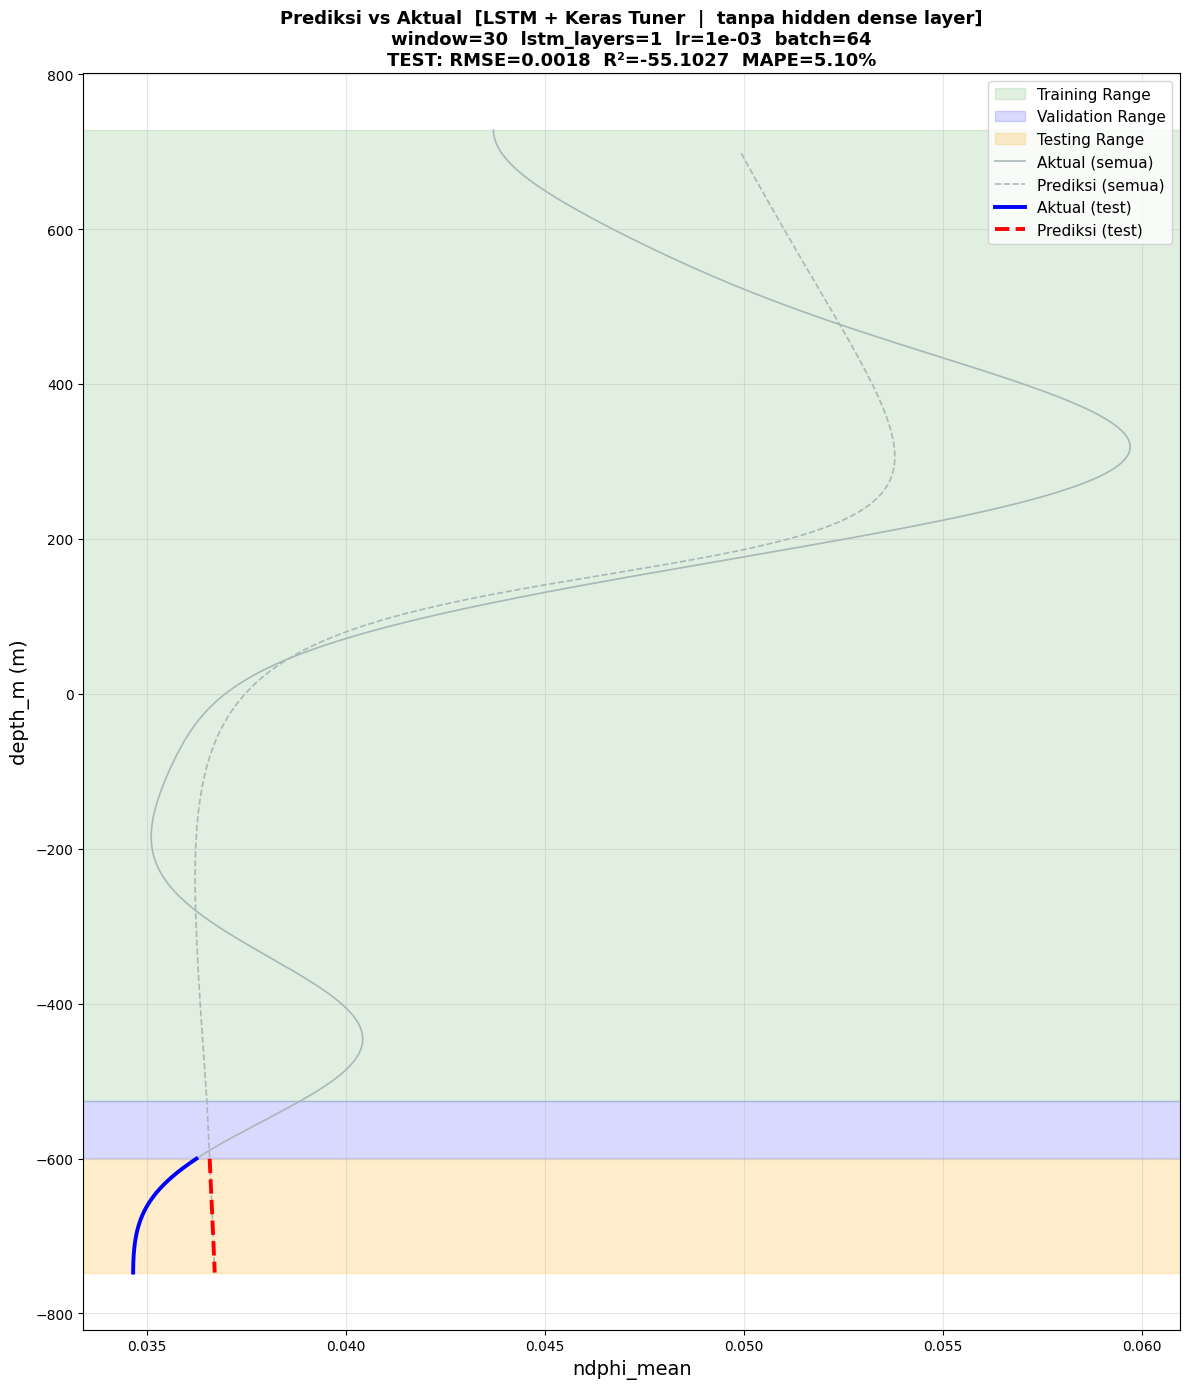

  Disimpan → lstm_depth_profile.png



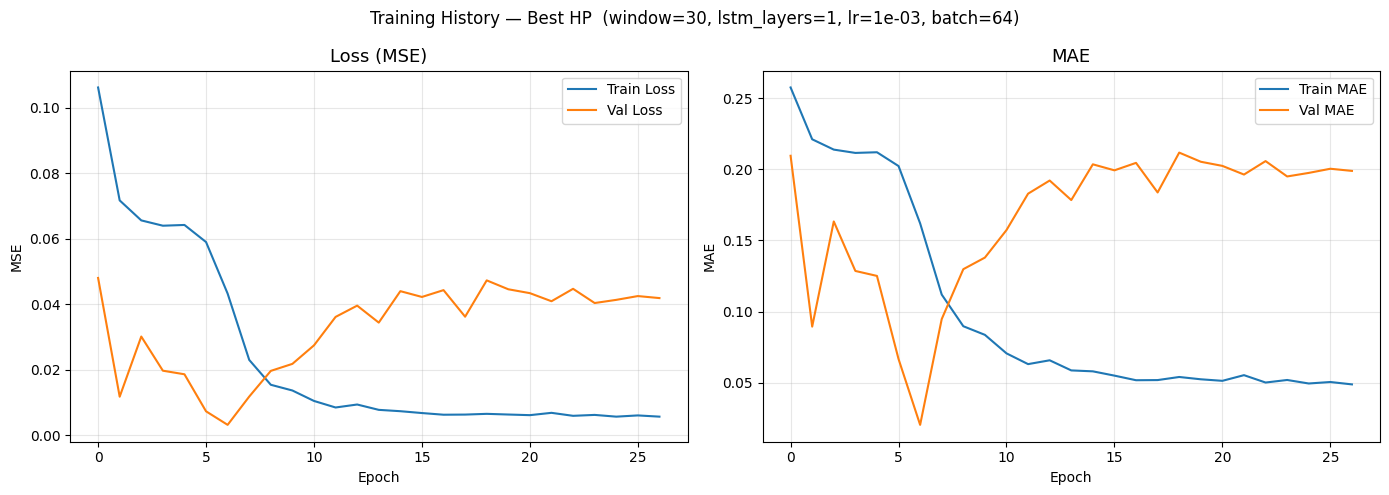

  Disimpan → lstm_training_history.png



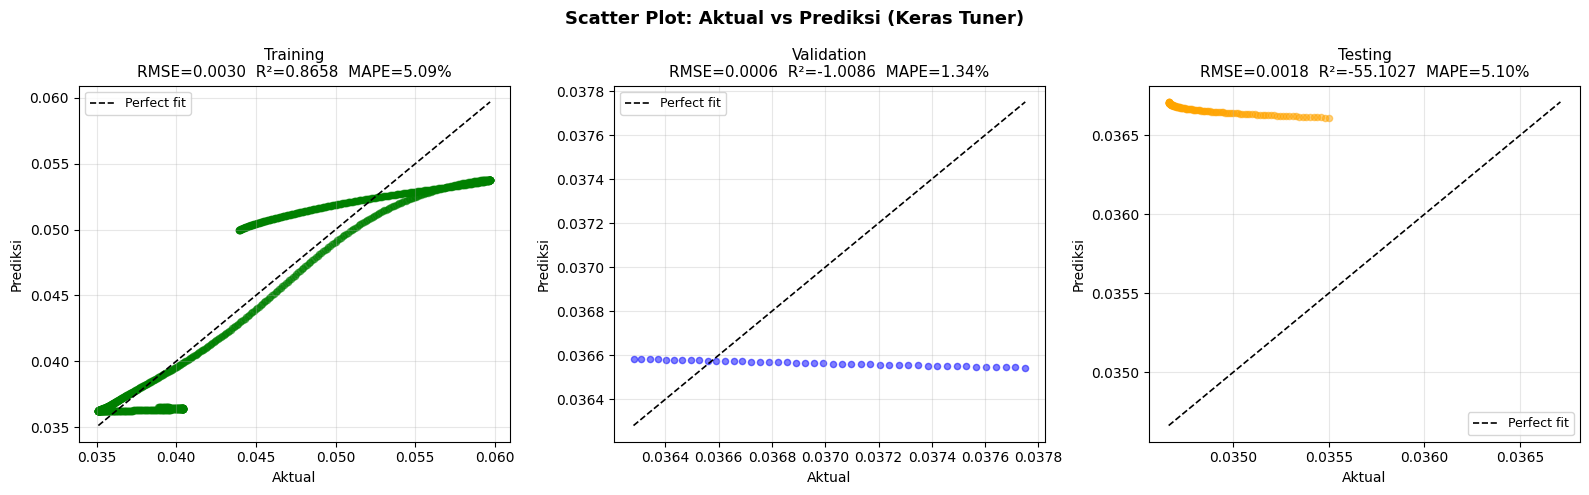

  Disimpan → lstm_scatter.png


  TOP 5 TRIALS (Keras Tuner):
  #1  val_loss=0.033888
       window=30  lstm_layers=1  lr=1e-03  batch=64
       {'window_size': 30, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 64, 'lstm_units_0': 64, 'dropout_lstm_0': 0.30000000000000004, 'lstm_units_1': 16, 'dropout_lstm_1': 0.1, 'lstm_units_2': 16, 'dropout_lstm_2': 0.1}
  #2  val_loss=0.034047
       window=30  lstm_layers=1  lr=1e-03  batch=64
       {'window_size': 30, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 64, 'lstm_units_0': 64, 'dropout_lstm_0': 0.30000000000000004, 'lstm_units_1': 32, 'dropout_lstm_1': 0.1, 'lstm_units_2': 16, 'dropout_lstm_2': 0.1}
  #3  val_loss=0.034237
       window=20  lstm_layers=1  lr=1e-03  batch=64
       {'window_size': 20, 'num_lstm_layers': 1, 'learning_rate': 0.001, 'batch_size': 64, 'lstm_units_0': 64, 'dropout_lstm_0': 0.2, 'lstm_units_1': 16, 'dropout_lstm_1': 0.1, 'lstm_units_2': 16, 'dropout_lstm_2': 0.1}
  #4  val_loss=0.0

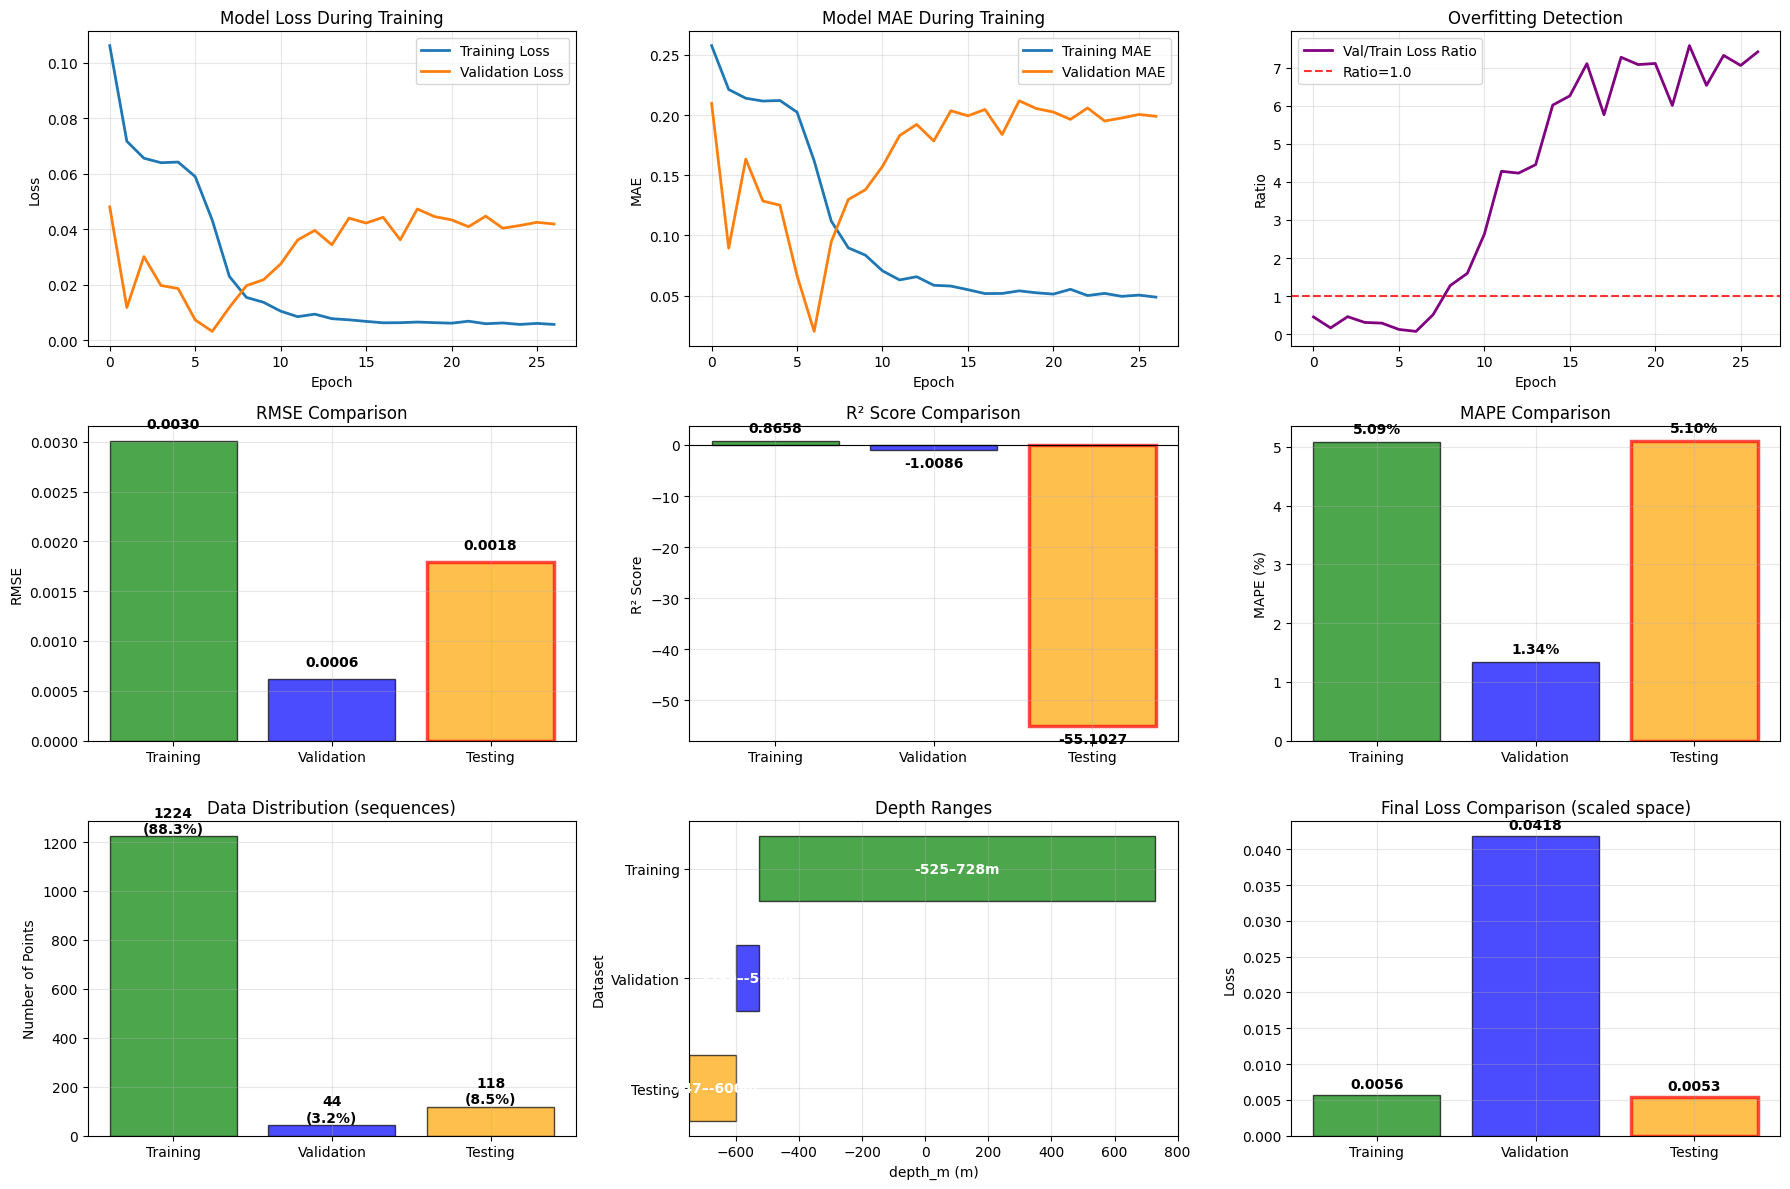

  Disimpan → lstm_comprehensive_analysis.png



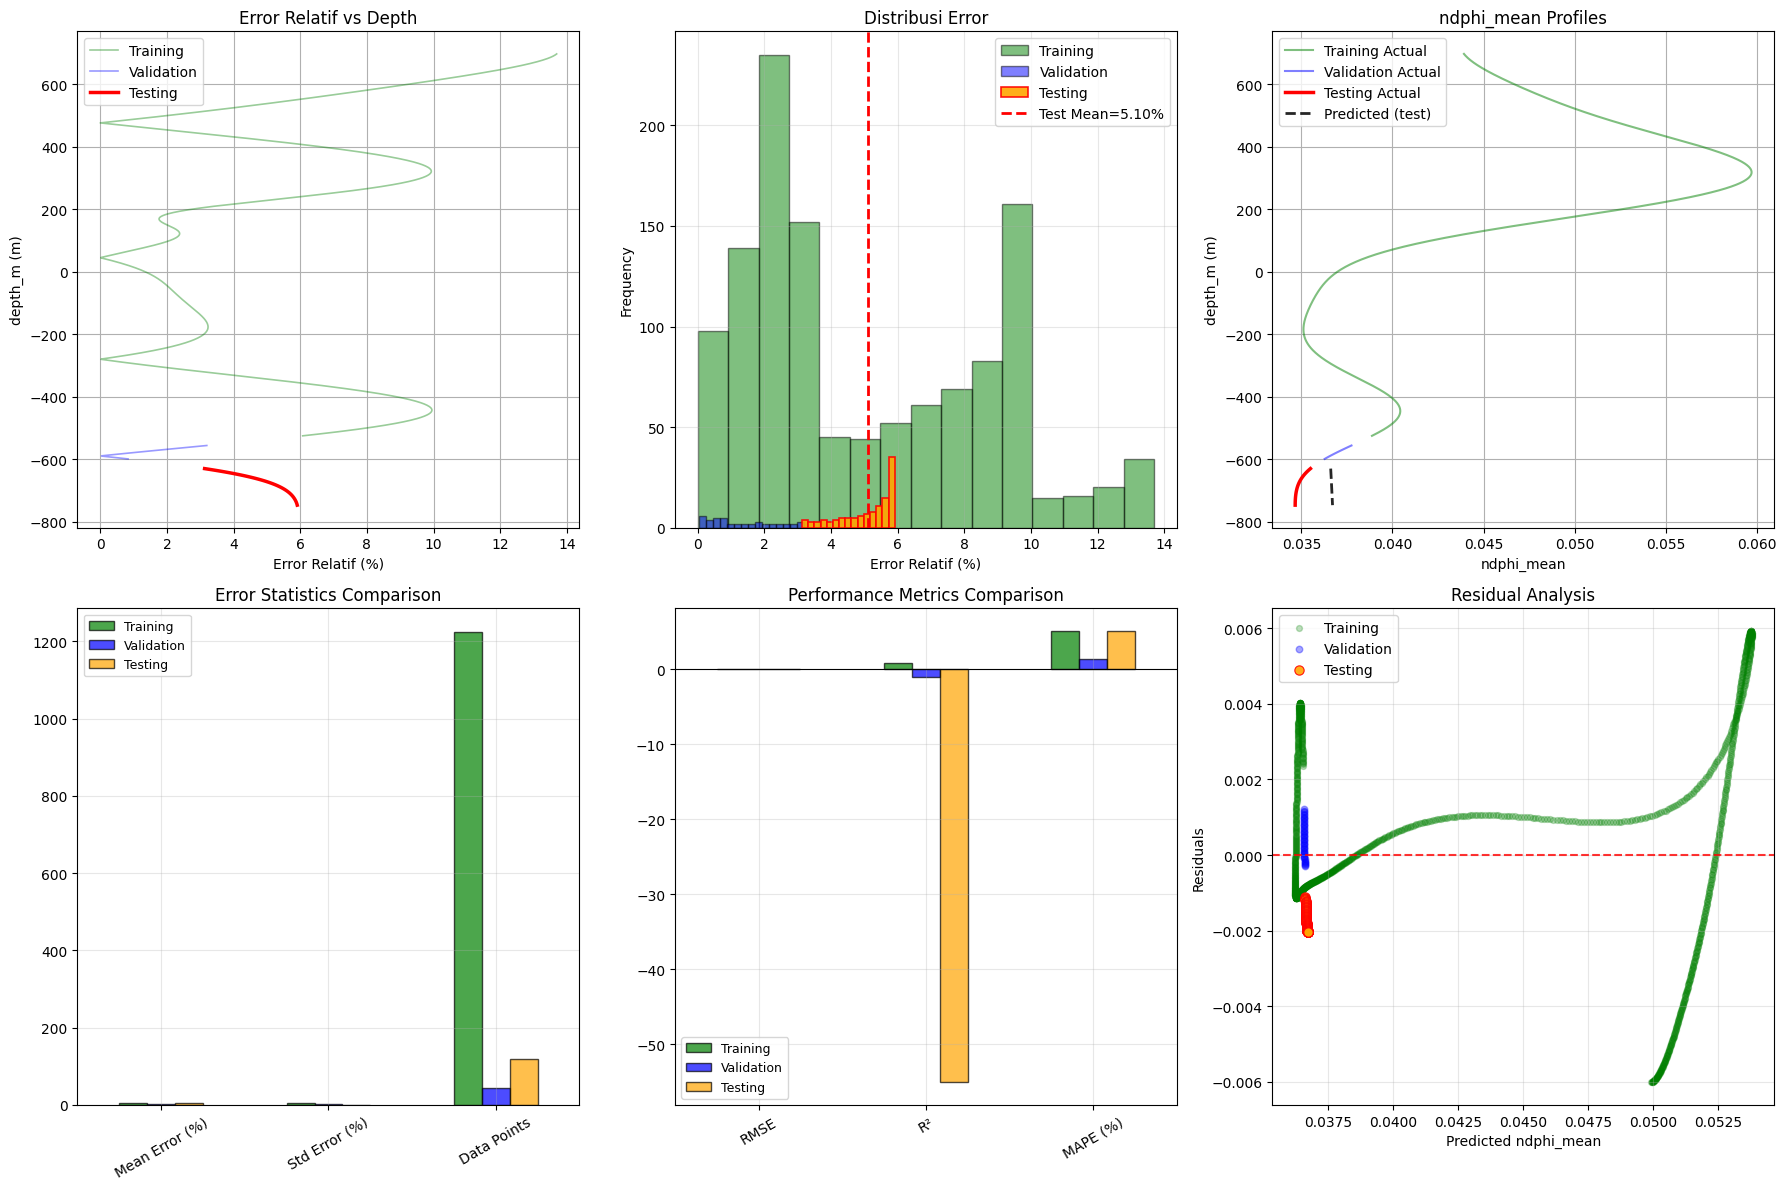

  Disimpan → lstm_error_analysis.png



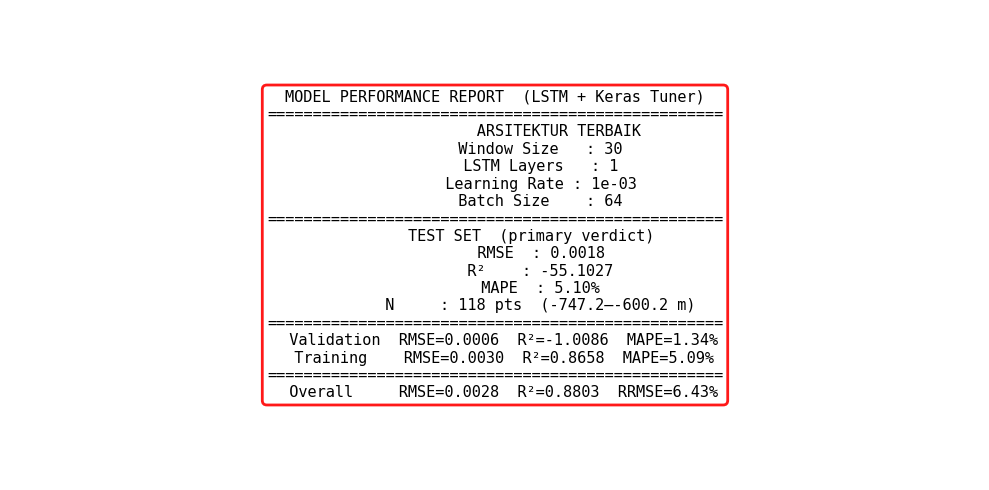

  Disimpan → lstm_metrics_summary.png

  File disimpan → lstm_predictions.csv

  Semua output berhasil dibuat!
    → lstm_depth_profile.png
    → lstm_training_history.png  (jika history tersedia)
    → lstm_scatter.png
    → lstm_comprehensive_analysis.png
    → lstm_error_analysis.png
    → lstm_metrics_summary.png
    → lstm_predictions.csv



In [1]:
# =============================================================================
#  LSTM + KERAS TUNER — Porosity Prediction (ndphi_mean)
#  Utah FORGE Site | Sumur FORGE 78B-32
#  Features : mt_res_ohmm + depth_m
#  Target   : ndphi_mean
#  Split    : depth-based  85 / 5 / 10  (train / val / test)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.regularizers import l2
import tensorflow as tf
import keras_tuner as kt
import math, os, random, joblib

# =============================================================================
# CONSTANTS
# =============================================================================
EPS      = 1e-10
DEPTH    = 'depth_m'
RES      = 'mt_res_ohmm'
PHI      = 'ndphi_mean'
PHI_PRED = 'ndphi_mean_pred'
ERR_COL  = 'Error_Relatif_Persen'
TYPE_COL = 'Data_Type'

# =============================================================================
# REPRODUCIBILITY
# =============================================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    print("Warning: deterministic ops not available on this device.")

# =============================================================================
# KERAS TUNER CONFIG
# =============================================================================
TUNER_DIR      = 'keras_tuner_results'
TUNER_PROJECT  = 'lstm_porosity'
MAX_TRIALS     = 200
TUNER_EPOCHS   = 50
TUNER_PATIENCE = 15
FINAL_EPOCHS   = 300
FINAL_PATIENCE = 20

# =============================================================================
# FILE PATHS
# =============================================================================
CSV_FILE      = 'resampled_1m_78B_AT90(ohm.m)_78.csv'
MODEL_FILE    = 'model_A_lstm_tuned.keras'
SCALER_X_PATH = 'scaler_X_A_lstm_tuned.pkl'
SCALER_Y_PATH = 'scaler_Y_A_lstm_tuned.pkl'
BEST_HP_PATH  = 'best_hp_lstm.pkl'
HISTORY_PATH  = 'training_history_lstm.pkl'
force_retrain = True

# =============================================================================
# OUTPUT FILENAMES
# =============================================================================
OUT_DEPTH         = 'lstm_depth_profile.png'
OUT_HISTORY       = 'lstm_training_history.png'
OUT_SCATTER       = 'lstm_scatter.png'
OUT_COMPREHENSIVE = 'lstm_comprehensive_analysis.png'
OUT_ERROR         = 'lstm_error_analysis.png'
OUT_SUMMARY       = 'lstm_metrics_summary.png'
OUT_CSV           = 'lstm_predictions.csv'

# =============================================================================
# SPLIT PERCENTAGES
# =============================================================================
TRAIN_PERC = 0.85
VAL_PERC   = 0.05
TEST_PERC  = 0.10

# =============================================================================
# 1) LOAD & SORT DATA
# =============================================================================
try:
    data = pd.read_csv(CSV_FILE, sep=';')
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan!")
    exit()

print(f"Data berhasil dimuat: {len(data)} baris")

data_sorted = data.sort_values(DEPTH, ascending=False).reset_index(drop=True)
min_z   = data_sorted[DEPTH].min()
max_z   = data_sorted[DEPTH].max()
z_range = max_z - min_z

test_limit  = min_z + z_range * TEST_PERC
test_mask   = data_sorted[DEPTH] <= test_limit

test_data      = data_sorted[test_mask]
train_val_data = data_sorted[~test_mask]

train_val_range = train_val_data[DEPTH].max() - train_val_data[DEPTH].min()
train_limit     = train_val_data[DEPTH].max() - train_val_range * (
    TRAIN_PERC / (1 - TEST_PERC))

train_data      = train_val_data[train_val_data[DEPTH] >  train_limit]
validation_data = train_val_data[train_val_data[DEPTH] <= train_limit]

print(f"Range keseluruhan : {max_z:.2f}m – {min_z:.2f}m")
print(f"Training range    : {train_data[DEPTH].max():.2f}m – {train_data[DEPTH].min():.2f}m  ({len(train_data)} pts)")
print(f"Validation range  : {validation_data[DEPTH].max():.2f}m – {validation_data[DEPTH].min():.2f}m  ({len(validation_data)} pts)")
print(f"Testing range     : {test_data[DEPTH].max():.2f}m – {test_data[DEPTH].min():.2f}m  ({len(test_data)} pts)")

# =============================================================================
# 2) RAW FEATURE ARRAYS
# =============================================================================
X_train_raw = train_data[[RES, DEPTH]].values
y_train_raw = train_data[[PHI]].values
X_val_raw   = validation_data[[RES, DEPTH]].values
y_val_raw   = validation_data[[PHI]].values
X_test_raw  = test_data[[RES, DEPTH]].values
y_test_raw  = test_data[[PHI]].values

N_FEATURES = X_train_raw.shape[1]  # = 2

# =============================================================================
# 3) SCALERS  (fit on train only)
# =============================================================================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train_raw)
y_train_sc = scaler_y.fit_transform(y_train_raw)
X_val_sc   = scaler_X.transform(X_val_raw)
y_val_sc   = scaler_y.transform(y_val_raw)
X_test_sc  = scaler_X.transform(X_test_raw)
y_test_sc  = scaler_y.transform(y_test_raw)

# =============================================================================
# 4) HELPER FUNCTIONS
# =============================================================================
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)


def predict_split(X_raw, y_raw, scaler_X, scaler_y, model, window_size):
    """Prediksi per split; return (y_true, y_pred) dalam satuan asli."""
    X_sc   = scaler_X.transform(X_raw)
    y_sc   = scaler_y.transform(y_raw)
    Xs, _  = create_sequences(X_sc, y_sc, window_size)
    y_pred = scaler_y.inverse_transform(
        model.predict(Xs, verbose=0)).flatten()
    y_true = y_raw[window_size:].flatten()
    return y_true, y_pred


def predict_all_aligned(X_raw, scaler_X, scaler_y, model, window_size):
    """Prediksi seluruh kolom data; NaN untuk window_size baris pertama."""
    X_sc  = scaler_X.transform(X_raw)
    seqs  = np.array([X_sc[i : i + window_size]
                      for i in range(len(X_sc) - window_size)])
    preds = scaler_y.inverse_transform(
        model.predict(seqs, verbose=0)).flatten()
    return np.concatenate([np.full(window_size, np.nan), preds])


def assign_data_type(z):
    if z <= test_limit:
        return 'Testing'
    elif z <= train_limit:
        return 'Validation'
    else:
        return 'Training'


def eval_metrics(y_true, y_pred):
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPS))) * 100
    return rmse, r2, mape


# =============================================================================
# 5) MODEL BUILDER — tuning jumlah LSTM layer {1,2,3}, tanpa hidden dense
# =============================================================================
def build_model(hp):
    window_size     = hp.Choice('window_size',     values=[3, 5, 10, 20, 30])
    num_lstm_layers = hp.Int   ('num_lstm_layers', min_value=1, max_value=3, step=1)
    lr              = hp.Choice('learning_rate',   values=[1e-3, 5e-4, 1e-4, 5e-5])
    hp.Choice('batch_size', values=[2, 4, 16, 32, 64])

    model = Sequential()

    for i in range(num_lstm_layers):
        units        = hp.Choice(f'lstm_units_{i}',  values=[16, 32, 64])
        dropout_rate = hp.Float (f'dropout_lstm_{i}',
                                  min_value=0.1, max_value=0.4, step=0.1)
        is_last_lstm = (i == num_lstm_layers - 1)

        if i == 0:
            model.add(LSTM(
                units,
                input_shape=(window_size, N_FEATURES),
                return_sequences=not is_last_lstm,
                kernel_regularizer=l2(1e-3),
                kernel_initializer=GlorotUniform(seed=SEED),
                recurrent_initializer='orthogonal',
                name=f'lstm_{i+1}'
            ))
        else:
            model.add(LSTM(
                units,
                return_sequences=not is_last_lstm,
                kernel_regularizer=l2(1e-3),
                kernel_initializer=GlorotUniform(seed=SEED),
                recurrent_initializer='orthogonal',
                name=f'lstm_{i+1}'
            ))

        model.add(Dropout(dropout_rate, seed=SEED, name=f'drop_lstm_{i+1}'))

    model.add(Dense(
        1,
        activation='linear',
        kernel_initializer=GlorotUniform(seed=SEED),
        name='output'
    ))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=MeanSquaredError(),
        metrics=['mae'],
    )
    return model


# =============================================================================
# 6) CUSTOM TUNER
# =============================================================================
class WindowedLSTMTuner(kt.BayesianOptimization):

    def run_trial(self, trial, epochs=TUNER_EPOCHS, callbacks=None, **kwargs):
        hp          = trial.hyperparameters
        window_size = hp.get('window_size') if 'window_size' in hp.values else 5
        batch_size  = hp.get('batch_size')  if 'batch_size'  in hp.values else 16

        X_tr, y_tr = create_sequences(X_train_sc, y_train_sc, window_size)
        X_v,  y_v  = create_sequences(X_val_sc,   y_val_sc,   window_size)

        model = self.hypermodel.build(hp)

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_v, y_v),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks or [],
            verbose=1,
        )

        # Penalize collapsed predictions
        val_preds = model.predict(X_v, verbose=0).flatten()
        pred_std  = np.std(val_preds)
        true_std  = np.std(y_val_sc[window_size:].flatten())
        std_ratio = pred_std / (true_std + 1e-8)
        penalty   = 0.05 * np.exp(-std_ratio)

        base_loss = min(history.history['val_loss'])
        score     = base_loss + penalty

        self.oracle.update_trial(trial.trial_id, {'val_loss': score})
        return history


# =============================================================================
# 7) RUN TUNER OR LOAD EXISTING MODEL
# =============================================================================
model_ready = (
    os.path.exists(MODEL_FILE)    and
    os.path.exists(SCALER_X_PATH) and
    os.path.exists(SCALER_Y_PATH) and
    os.path.exists(BEST_HP_PATH)  and
    not force_retrain
)

if model_ready:
    print("\nMemuat model & scaler yang sudah ada …")
    try:
        model    = load_model(MODEL_FILE)
        scaler_X = joblib.load(SCALER_X_PATH)
        scaler_y = joblib.load(SCALER_Y_PATH)
        best_hp  = joblib.load(BEST_HP_PATH)
        WINDOW_SIZE = best_hp['window_size']
        print(f"Model dimuat. Window size terbaik : {WINDOW_SIZE}")
        print(f"Jumlah LSTM layer terbaik         : {best_hp.get('num_lstm_layers')}")
    except Exception as e:
        print(f"Gagal memuat: {e}\nMelatih ulang …")
        force_retrain = True

if force_retrain:
    tuner = WindowedLSTMTuner(
        hypermodel           = build_model,
        objective            = kt.Objective('val_loss', direction='min'),
        max_trials           = MAX_TRIALS,
        executions_per_trial = 1,
        seed                 = SEED,
        directory            = TUNER_DIR,
        project_name         = TUNER_PROJECT,
        overwrite            = True,
    )

    tuner.search_space_summary()

    search_callbacks = [
        EarlyStopping(monitor='val_loss', patience=TUNER_PATIENCE,
                      restore_best_weights=True),
    ]

    print("\n" + "="*60)
    print("  MULAI KERAS TUNER SEARCH …")
    print(f"  Max trials : {MAX_TRIALS}  |  Epochs/trial : {TUNER_EPOCHS}")
    print("="*60 + "\n")

    tuner.search(
        epochs    = TUNER_EPOCHS,
        callbacks = search_callbacks,
    )

    best_hp_obj   = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_hp       = best_hp_obj.values
    WINDOW_SIZE   = best_hp['window_size']
    best_batch    = best_hp.get('batch_size', 16)
    best_num_lstm = best_hp.get('num_lstm_layers', 2)

    print("\n" + "="*60)
    print("  HYPERPARAMETER TERBAIK:")
    for k, v in best_hp.items():
        print(f"    {k:<25} = {v}")
    print("="*60 + "\n")

    X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train_sc, WINDOW_SIZE)
    X_val_seq,   y_val_seq   = create_sequences(X_val_sc,   y_val_sc,   WINDOW_SIZE)
    X_test_seq,  y_test_seq  = create_sequences(X_test_sc,  y_test_sc,  WINDOW_SIZE)

    print(f"Sequence shapes (window={WINDOW_SIZE}, batch={best_batch}, lstm_layers={best_num_lstm}):")
    print(f"  Train : {X_train_seq.shape}")
    print(f"  Val   : {X_val_seq.shape}")
    print(f"  Test  : {X_test_seq.shape}\n")

    model = tuner.hypermodel.build(best_hp_obj)
    model.summary()

    final_callbacks = [
        EarlyStopping(monitor='val_loss', patience=FINAL_PATIENCE,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                         patience=5, min_lr=1e-6),
    ]

    print("\nMelatih model final dengan HP terbaik …")
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=FINAL_EPOCHS,
        batch_size=best_batch,
        callbacks=final_callbacks,
        verbose=1,
    )

    # Simpan history untuk digunakan di plotting
    joblib.dump(history.history, HISTORY_PATH)

    try:
        model.save(MODEL_FILE)
        joblib.dump(scaler_X, SCALER_X_PATH)
        joblib.dump(scaler_y, SCALER_Y_PATH)
        joblib.dump(best_hp,  BEST_HP_PATH)
        print(f"\nModel disimpan → {MODEL_FILE}")
    except Exception as e:
        print(f"Warning: tidak bisa menyimpan: {e}")

# =============================================================================
# 8) LABEL DATA TYPE
# =============================================================================
data_sorted[TYPE_COL] = data_sorted[DEPTH].apply(assign_data_type)

# =============================================================================
# 9) EVALUATE
# =============================================================================
y_true_train, y_pred_train = predict_split(
    X_train_raw, y_train_raw, scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_val,   y_pred_val   = predict_split(
    X_val_raw,   y_val_raw,   scaler_X, scaler_y, model, WINDOW_SIZE)
y_true_test,  y_pred_test  = predict_split(
    X_test_raw,  y_test_raw,  scaler_X, scaler_y, model, WINDOW_SIZE)

all_preds  = predict_all_aligned(
    data_sorted[[RES, DEPTH]].values, scaler_X, scaler_y, model, WINDOW_SIZE)

valid_mask = ~np.isnan(all_preds)
y_true_all = data_sorted[PHI].values[valid_mask]
y_pred_all = all_preds[valid_mask]

rmse_train, r2_train, mape_train = eval_metrics(y_true_train, y_pred_train)
rmse_val,   r2_val,   mape_val   = eval_metrics(y_true_val,   y_pred_val)
rmse_test,  r2_test,  mape_test  = eval_metrics(y_true_test,  y_pred_test)
rmse_overall, r2_overall, mape_overall = eval_metrics(y_true_all, y_pred_all)
rrmse_overall = np.sqrt(np.sum((y_true_all - y_pred_all)**2) /
                        (np.sum(y_true_all**2) + EPS)) * 100

data_sorted[PHI_PRED] = all_preds
data_sorted[ERR_COL]  = (
    np.abs(data_sorted[PHI].values - all_preds) /
    (np.abs(data_sorted[PHI].values) + EPS)
) * 100

train_sc     = data_sorted[data_sorted[TYPE_COL] == 'Training'].copy()
val_sc       = data_sorted[data_sorted[TYPE_COL] == 'Validation'].copy()
test_sc      = data_sorted[data_sorted[TYPE_COL] == 'Testing'].copy()
train_depths = train_sc[DEPTH]
val_depths   = val_sc[DEPTH]
test_depths  = test_sc[DEPTH]

# Depth sequences (offset = WINDOW_SIZE)
W = WINDOW_SIZE
depth_train_seq = train_data[DEPTH].values[W:]
depth_val_seq   = validation_data[DEPTH].values[W:]
depth_test_seq  = test_data[DEPTH].values[W:]

train_d_min = train_data[DEPTH].min()
train_d_max = train_data[DEPTH].max()
val_d_min   = validation_data[DEPTH].min()
val_d_max   = validation_data[DEPTH].max()
test_d_min  = test_data[DEPTH].min()
test_d_max  = test_data[DEPTH].max()

# Relative error & residuals
err_train = np.abs(y_true_train - y_pred_train) / (np.abs(y_true_train) + EPS) * 100
err_val   = np.abs(y_true_val   - y_pred_val)   / (np.abs(y_true_val)   + EPS) * 100
err_test  = np.abs(y_true_test  - y_pred_test)  / (np.abs(y_true_test)  + EPS) * 100

res_train = y_true_train - y_pred_train
res_val   = y_true_val   - y_pred_val
res_test  = y_true_test  - y_pred_test

# =============================================================================
# 10) PRINT RESULTS
# =============================================================================
W_line = 80
print("\n" + "=" * W_line)
print(f"  EVALUASI MODEL LSTM + KERAS TUNER  (tanpa hidden dense layer)")
print(f"  Best HP : window={WINDOW_SIZE}"
      f"  lstm_layers={best_hp.get('num_lstm_layers')}"
      f"  lr={best_hp.get('learning_rate'):.0e}"
      f"  batch={best_hp.get('batch_size')}")
print("=" * W_line)
print(f"  {'Metrik':<22} {'Training':>12} {'Validation':>12} {'TEST':>12} {'Overall':>12}")
print("-" * W_line)
print(f"  {'RMSE':<22} {rmse_train:>12.4f} {rmse_val:>12.4f} {rmse_test:>12.4f} {rmse_overall:>12.4f}")
print(f"  {'R² Score':<22} {r2_train:>12.4f} {r2_val:>12.4f} {r2_test:>12.4f} {r2_overall:>12.4f}")
print(f"  {'MAPE (%)':<22} {mape_train:>12.2f} {mape_val:>12.2f} {mape_test:>12.2f} {mape_overall:>12.2f}")
print("-" * W_line)
print(f"  {'Data Points (valid)':<22} {len(y_true_train):>12} {len(y_true_val):>12} {len(y_true_test):>12} {valid_mask.sum():>12}")
print(f"  {'RRMSE Overall (%)':<22} {'':>12} {'':>12} {'':>12} {rrmse_overall:>12.2f}")
print("=" * W_line)
print(f"  >>> TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%  <<<")
print("=" * W_line)

# =============================================================================
# PLOT 1: DEPTH PROFILE  (section 12)
# =============================================================================
plt.figure(figsize=(12, 14))

if len(train_depths): plt.axhspan(train_depths.min(), train_depths.max(), alpha=0.12, color='green',  label='Training Range',   zorder=1)
if len(val_depths):   plt.axhspan(val_depths.min(),   val_depths.max(),   alpha=0.15, color='blue',   label='Validation Range', zorder=1)
if len(test_depths):  plt.axhspan(test_depths.min(),  test_depths.max(),  alpha=0.20, color='orange', label='Testing Range',    zorder=1)

plt.plot(data_sorted[PHI],      data_sorted[DEPTH], '-',  color='#aab7b8', lw=1.2, label='Aktual (semua)',   zorder=2)
plt.plot(data_sorted[PHI_PRED], data_sorted[DEPTH], '--', color='#aab7b8', lw=1.2, label='Prediksi (semua)', zorder=2)
plt.plot(test_sc[PHI],          test_sc[DEPTH],     '-',  color='blue',    lw=2.8, label='Aktual (test)',    zorder=4)
plt.plot(test_sc[PHI_PRED],     test_sc[DEPTH],     '--', color='red',     lw=2.8, label='Prediksi (test)',  zorder=4)

plt.xlabel(PHI, fontsize=14)
plt.ylabel(f'{DEPTH} (m)', fontsize=14)
plt.title(
    f'Prediksi vs Aktual  [LSTM + Keras Tuner  |  tanpa hidden dense layer]\n'
    f'window={WINDOW_SIZE}  '
    f'lstm_layers={best_hp.get("num_lstm_layers")}  '
    f'lr={best_hp.get("learning_rate"):.0e}  '
    f'batch={best_hp.get("batch_size")}\n'
    f'TEST: RMSE={rmse_test:.4f}  R²={r2_test:.4f}  MAPE={mape_test:.2f}%',
    fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DEPTH, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_DEPTH}\n")

# =============================================================================
# PLOT 2: TRAINING HISTORY  (section 13)
# =============================================================================
if os.path.exists(HISTORY_PATH):
    hist = joblib.load(HISTORY_PATH)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist['loss'],     label='Train Loss')
    axes[0].plot(hist['val_loss'], label='Val Loss')
    axes[0].set_title('Loss (MSE)', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    mae_key  = 'mae'     if 'mae'     in hist else [k for k in hist if 'mae' in k and 'val' not in k][0]
    vmae_key = 'val_mae' if 'val_mae' in hist else [k for k in hist if 'val' in k and 'mae' in k][0]
    axes[1].plot(hist[mae_key],  label='Train MAE')
    axes[1].plot(hist[vmae_key], label='Val MAE')
    axes[1].set_title('MAE', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f'Training History — Best HP  '
        f'(window={WINDOW_SIZE}, '
        f'lstm_layers={best_hp.get("num_lstm_layers")}, '
        f'lr={best_hp.get("learning_rate"):.0e}, '
        f'batch={best_hp.get("batch_size")})',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_HISTORY, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Disimpan → {OUT_HISTORY}\n")

# =============================================================================
# PLOT 3: SCATTER PLOT  (section 14)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits_plot = [
    ('Training',   y_true_train, y_pred_train, 'green',  rmse_train, r2_train, mape_train),
    ('Validation', y_true_val,   y_pred_val,   'blue',   rmse_val,   r2_val,   mape_val),
    ('Testing',    y_true_test,  y_pred_test,  'orange', rmse_test,  r2_test,  mape_test),
]
for ax, (title, yt, yp, col, rmse, r2, mape) in zip(axes, splits_plot):
    ax.scatter(yt, yp, alpha=0.5, color=col, s=20)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect fit')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')
    ax.set_title(f'{title}\nRMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot: Aktual vs Prediksi (Keras Tuner)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SCATTER}\n")

# =============================================================================
# PLOT 4: TOP 5 TRIALS  (section 15)
# =============================================================================
if force_retrain:
    print("\n" + "="*60)
    print("  TOP 5 TRIALS (Keras Tuner):")
    print("="*60)
    try:
        best_trials = tuner.oracle.get_best_trials(num_trials=5)
        for rank, trial in enumerate(best_trials, 1):
            hp_vals = trial.hyperparameters.values
            score   = trial.score
            print(f"  #{rank}  val_loss={score:.6f}")
            print(f"       window={hp_vals.get('window_size')}  "
                  f"lstm_layers={hp_vals.get('num_lstm_layers')}  "
                  f"lr={hp_vals.get('learning_rate'):.0e}  "
                  f"batch={hp_vals.get('batch_size')}")
            print(f"       {hp_vals}")
    except Exception as e:
        print(f"  (Could not retrieve trial summary: {e})")
    print("="*60)

# =============================================================================
# PLOT 5: COMPREHENSIVE ANALYSIS (3×3)
# =============================================================================
datasets   = ['Training', 'Validation', 'Testing']
colors_bar = ['green', 'blue', 'orange']

plt.figure(figsize=(18, 12))

# ── Loss curve ──────────────────────────────────────────────────────────────
plt.subplot(3, 3, 1)
if os.path.exists(HISTORY_PATH):
    plt.plot(hist['loss'],     label='Training Loss',   linewidth=2)
    plt.plot(hist['val_loss'], label='Validation Loss', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model Loss During Training')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

# ── MAE curve ────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 2)
if os.path.exists(HISTORY_PATH):
    plt.plot(hist[mae_key],  label='Training MAE',   linewidth=2)
    plt.plot(hist[vmae_key], label='Validation MAE', linewidth=2)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Model MAE During Training')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.legend(); plt.grid(True, alpha=0.3)

# ── Overfitting detection ─────────────────────────────────────────────────────
plt.subplot(3, 3, 3)
if os.path.exists(HISTORY_PATH):
    tl = np.array(hist['loss'])
    vl = np.array(hist['val_loss'])
    plt.plot(vl / (tl + EPS), label='Val/Train Loss Ratio',
             linewidth=2, color='purple')
    plt.axhline(y=1.0, color='r', linestyle='--', label='Ratio=1.0', alpha=0.8)
else:
    plt.text(0.5, 0.5, 'History tidak tersedia', ha='center',
             va='center', transform=plt.gca().transAxes, color='grey')
plt.title('Overfitting Detection')
plt.xlabel('Epoch'); plt.ylabel('Ratio')
plt.legend(); plt.grid(True, alpha=0.3)

# ── RMSE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 4)
rmse_vals = [rmse_train, rmse_val, rmse_test]
bars = plt.bar(datasets, rmse_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('RMSE Comparison'); plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.0001,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# ── R² bar ────────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 5)
r2_vals = [r2_train, r2_val, r2_test]
bars = plt.bar(datasets, r2_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('R² Score Comparison'); plt.ylabel('R² Score')
plt.axhline(0, color='black', lw=0.8)
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, r2_vals):
    offset = abs(max(r2_vals) - min(r2_vals)) * 0.02
    ypos   = v + offset if v >= 0 else v - offset
    va     = 'bottom'   if v >= 0 else 'top'
    plt.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{v:.4f}', ha='center', va=va, fontweight='bold')

# ── MAPE bar ──────────────────────────────────────────────────────────────────
plt.subplot(3, 3, 6)
mape_vals = [mape_train, mape_val, mape_test]
bars = plt.bar(datasets, mape_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('MAPE Comparison'); plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
for bar, v in zip(bars, mape_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# ── Data distribution ─────────────────────────────────────────────────────────
plt.subplot(3, 3, 7)
data_counts = [len(y_true_train), len(y_true_val), len(y_true_test)]
total_pts   = sum(data_counts)
bars = plt.bar(datasets, data_counts, color=colors_bar, alpha=0.7, edgecolor='black')
plt.title('Data Distribution (sequences)'); plt.ylabel('Number of Points')
plt.grid(True, alpha=0.3)
for bar, cnt in zip(bars, data_counts):
    pct = cnt / (total_pts + EPS) * 100
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{cnt}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

# ── Depth ranges ──────────────────────────────────────────────────────────────
plt.subplot(3, 3, 8)
depth_ranges = {
    'Training':   [train_d_min, train_d_max],
    'Validation': [val_d_min,   val_d_max],
    'Testing':    [test_d_min,  test_d_max],
}
for i, (name, (d_min, d_max)) in enumerate(depth_ranges.items()):
    if np.isfinite(d_min) and np.isfinite(d_max):
        plt.barh(i, d_max - d_min, left=d_min, height=0.6,
                 color=colors_bar[i], alpha=0.7, edgecolor='black')
        plt.text(d_min + (d_max - d_min) / 2, i,
                 f'{d_min:.0f}–{d_max:.0f}m',
                 ha='center', va='center', fontweight='bold', color='white')
plt.xlabel(f'{DEPTH} (m)'); plt.ylabel('Dataset')
plt.title('Depth Ranges')
plt.yticks(range(3), list(depth_ranges.keys()))
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()

# ── Final loss comparison (scaled space) ──────────────────────────────────────
plt.subplot(3, 3, 9)
if os.path.exists(HISTORY_PATH):
    final_train_loss = hist['loss'][-1]
    final_val_loss   = hist['val_loss'][-1]
else:
    final_train_loss = float('nan')
    final_val_loss   = float('nan')

y_test_sc_off    = scaler_y.transform(y_test_raw)[W:].flatten()
yp_test_sc_final = model.predict(
    np.array([scaler_X.transform(X_test_raw)[i : i + W]
              for i in range(len(X_test_raw) - W)]),
    verbose=0).flatten()
final_test_loss  = float(np.mean((y_test_sc_off - yp_test_sc_final) ** 2))

loss_vals = [final_train_loss, final_val_loss, final_test_loss]
bars = plt.bar(datasets, loss_vals, color=colors_bar, alpha=0.7, edgecolor='black')
bars[2].set_edgecolor('red'); bars[2].set_linewidth(2.5)
plt.title('Final Loss Comparison (scaled space)')
plt.ylabel('Loss'); plt.grid(True, alpha=0.3)
for bar, v in zip(bars, loss_vals):
    if np.isfinite(v):
        plt.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(x for x in loss_vals if np.isfinite(x)) * 0.015,
                 f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_COMPREHENSIVE, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_COMPREHENSIVE}\n")

# =============================================================================
# PLOT 6: ERROR ANALYSIS (2×3)
# =============================================================================
plt.figure(figsize=(18, 12))

# ── Error Relatif vs Depth ────────────────────────────────────────────────────
plt.subplot(2, 3, 1)
plt.plot(err_train, depth_train_seq, 'g-', lw=1.2, label='Training',   alpha=0.4)
plt.plot(err_val,   depth_val_seq,   'b-', lw=1.2, label='Validation', alpha=0.4)
plt.plot(err_test,  depth_test_seq,  'r-', lw=2.5, label='Testing',    alpha=1.0)
plt.xlabel('Error Relatif (%)'); plt.ylabel(f'{DEPTH} (m)')
plt.title('Error Relatif vs Depth')
plt.legend(); plt.grid(True)

# ── Distribusi Error ──────────────────────────────────────────────────────────
plt.subplot(2, 3, 2)
plt.hist(err_train, bins=15, alpha=0.5, color='green',
         label='Training',   edgecolor='black')
plt.hist(err_val,   bins=15, alpha=0.5, color='blue',
         label='Validation', edgecolor='black')
plt.hist(err_test,  bins=15, alpha=0.9, color='orange',
         label='Testing',    edgecolor='red', linewidth=1.2)
plt.axvline(err_test.mean(), color='red', lw=2, linestyle='--',
            label=f'Test Mean={err_test.mean():.2f}%')
plt.xlabel('Error Relatif (%)'); plt.ylabel('Frequency')
plt.title('Distribusi Error')
plt.legend(); plt.grid(True, alpha=0.3)

# ── ndphi_mean Profiles ───────────────────────────────────────────────────────
plt.subplot(2, 3, 3)
plt.plot(y_true_train, depth_train_seq, 'g-',  lw=1.5,
         label='Training Actual',   alpha=0.5)
plt.plot(y_true_val,   depth_val_seq,   'b-',  lw=1.5,
         label='Validation Actual', alpha=0.5)
plt.plot(y_true_test,  depth_test_seq,  'r-',  lw=2.5,
         label='Testing Actual',    alpha=1.0)
plt.plot(y_pred_test,  depth_test_seq,  'k--', lw=2.0,
         label='Predicted (test)',  alpha=0.85)
plt.xlabel(PHI); plt.ylabel(f'{DEPTH} (m)')
plt.title(f'{PHI} Profiles')
plt.legend(); plt.grid(True)

# ── Error Statistics Comparison ───────────────────────────────────────────────
plt.subplot(2, 3, 4)
stats_data = {
    'Training':   [err_train.mean(), err_train.std(), len(y_true_train)],
    'Validation': [err_val.mean(),   err_val.std(),   len(y_true_val)],
    'Testing':    [err_test.mean(),  err_test.std(),  len(y_true_test)],
}
stats_df = pd.DataFrame(
    stats_data,
    index=['Mean Error (%)', 'Std Error (%)', 'Data Points'])
stats_df.plot(kind='bar', ax=plt.gca(),
              color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Error Statistics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)

# ── Performance Metrics Comparison ───────────────────────────────────────────
plt.subplot(2, 3, 5)
metrics_data = {
    'Training':   [rmse_train, r2_train, mape_train],
    'Validation': [rmse_val,   r2_val,   mape_val],
    'Testing':    [rmse_test,  r2_test,  mape_test],
}
metrics_df = pd.DataFrame(
    metrics_data,
    index=['RMSE', 'R²', 'MAPE (%)'])
metrics_df.plot(kind='bar', ax=plt.gca(),
                color=['green', 'blue', 'orange'], alpha=0.7, edgecolor='black')
plt.title('Performance Metrics Comparison')
plt.xticks(rotation=30); plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.axhline(0, color='black', lw=0.8)

# ── Residual Analysis ─────────────────────────────────────────────────────────
plt.subplot(2, 3, 6)
plt.scatter(y_pred_train, res_train, alpha=0.25, color='green',
            label='Training',   s=18)
plt.scatter(y_pred_val,   res_val,   alpha=0.35, color='blue',
            label='Validation', s=22)
plt.scatter(y_pred_test,  res_test,  alpha=0.90, color='orange',
            label='Testing',    s=45,
            zorder=4, edgecolors='red', linewidths=0.8)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.8)
plt.xlabel(f'Predicted {PHI}'); plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_ERROR, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_ERROR}\n")

# =============================================================================
# PLOT 7: SUMMARY BOX
# =============================================================================
plt.figure(figsize=(10, 5))
plt.axis('off')

textstr = (
    f"MODEL PERFORMANCE REPORT  (LSTM + Keras Tuner)\n"
    f"{'='*50}\n"
    f"              ARSITEKTUR TERBAIK\n"
    f"          Window Size   : {WINDOW_SIZE}\n"
    f"          LSTM Layers   : {best_hp.get('num_lstm_layers')}\n"
    f"          Learning Rate : {best_hp.get('learning_rate'):.0e}\n"
    f"          Batch Size    : {best_hp.get('batch_size')}\n"
    f"{'='*50}\n"
    f"        TEST SET  (primary verdict)\n"
    f"          RMSE  : {rmse_test:.4f}\n"
    f"          R²    : {r2_test:.4f}\n"
    f"          MAPE  : {mape_test:.2f}%\n"
    f"          N     : {len(y_true_test)} pts  ({test_d_min:.1f}–{test_d_max:.1f} m)\n"
    f"{'='*50}\n"
    f"  Validation  RMSE={rmse_val:.4f}  R²={r2_val:.4f}  MAPE={mape_val:.2f}%\n"
    f"  Training    RMSE={rmse_train:.4f}  R²={r2_train:.4f}  MAPE={mape_train:.2f}%\n"
    f"{'='*50}\n"
    f"  Overall     RMSE={rmse_overall:.4f}  R²={r2_overall:.4f}  RRMSE={rrmse_overall:.2f}%"
)

plt.text(0.5, 0.5, textstr, transform=plt.gca().transAxes,
         fontsize=11, va='center', ha='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white',
                   edgecolor='red', linewidth=2, alpha=0.9))
plt.tight_layout()
plt.savefig(OUT_SUMMARY, dpi=300, bbox_inches='tight')
plt.show()
print(f"  Disimpan → {OUT_SUMMARY}\n")

# =============================================================================
# EXPORT CSV
# =============================================================================
results_frames = []
for label, df_split, X_raw, y_raw in [
    ('Training',   train_data,      X_train_raw, y_train_raw),
    ('Validation', validation_data, X_val_raw,   y_val_raw),
    ('Testing',    test_data,       X_test_raw,  y_test_raw),
]:
    y_true_v, y_pred_v = predict_split(
        X_raw, y_raw, scaler_X, scaler_y, model, W)
    depth_v = df_split[DEPTH].values[W:]
    frame = pd.DataFrame({
        DEPTH    : depth_v,
        PHI      : y_true_v,
        PHI_PRED : y_pred_v,
        ERR_COL  : np.where(
            np.abs(y_true_v) > EPS,
            np.abs((y_true_v - y_pred_v) / y_true_v) * 100,
            np.nan),
        TYPE_COL : label,
    })
    results_frames.append(frame)

results_df = pd.concat(results_frames, ignore_index=True)
results_df.to_csv(OUT_CSV, index=False)
print(f"  File disimpan → {OUT_CSV}")

# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n  Semua output berhasil dibuat!")
print(f"    → {OUT_DEPTH}")
print(f"    → {OUT_HISTORY}  (jika history tersedia)")
print(f"    → {OUT_SCATTER}")
print(f"    → {OUT_COMPREHENSIVE}")
print(f"    → {OUT_ERROR}")
print(f"    → {OUT_SUMMARY}")
print(f"    → {OUT_CSV}\n")